# Chapter 4 — Ice Edge Detection

*Sea Ice Image Processing with MATLAB* (Q. Zhang & R. Skjetne, CRC Press 2018), Chapter 4, pp. 59–82 —
Python port `seaice-py`, notebook `notebooks/ch04_ice_edge_detection.ipynb`.

**Sections covered** (one notebook section each, in book order):
4.1.1 Gradient operator (Eqs. 4.1–4.8, Figs. 4.1–4.3) · 4.1.2 Laplacian, Gaussian and LoG (Eqs. 4.9–4.15,
Figs. 4.4–4.6) · 4.2 Structuring elements (Fig. 4.7) · 4.2.1 Erosion and dilation (Eqs. 4.16–4.21, Figs. 4.8–4.10) ·
4.2.2 Closing and opening (Eqs. 4.22–4.23, Figs. 4.11–4.12) · 4.2.3 Morphological reconstruction (Eqs. 4.24–4.38,
Figs. 4.13–4.14) · 4.2.4 Morphological gradient (Eqs. 4.39–4.42, Figs. 4.15–4.16) · 4.3 Experimental results
(Figs. 4.17–4.20).

The output of this chapter is a **binary edge map** — from the first derivative (Sobel / Prewitt), from zero-crossings
of the second derivative (LoG) or from morphological gradients of the Chapter 3 ice mask — and, more importantly for
Chapters 5–9, the **morphological primitives** (`strel`, `imerode`, `imdilate`, opening / closing, reconstruction).

**MATLAB files this notebook replaces** (`MATLAB_ROOT/ch4/`):

| MATLAB file | Python (imported below) | Parity (from `reports/ch04_verification.md`, MATLAB R2025a as reference) |
|---|---|---|
| `derivative.m` (`im = double(rgb2gray(im))/256; BW = edge(im, 'sobel', 0.05)`) | `seaice.ch04_ice_edge_detection.sobel_edges_script` → `seaice.core.edges.edge` (MATLAB's `edge` re-implemented: `/8` kernels, replicate padding, `T²` cutoff, thinning) | exact (edge map 0 px differ on 12.25 Mpx; 11 `edge` variants incl. Prewitt / LoG / automatic T all 0 px) |
| `morphology.m` (`strel('dis', 7)`, `im2bw(im, graythresh(im))`, `imerode`, `imdilate`, `I − J`, `K − I`, `K − J`, gray `im − X` …) | `morphological_edges` → `seaice.core.morphology.strel / imerode / imdilate / morphological_gradient` | exact (all 12 arrays 0 px / 0 levels; `strel('dis', 7)` = MATLAB's 13×13 / 157-px approximate disk) |
| *(text only: Eqs. 4.1–4.15, Figs. 4.1–4.2, 4.4–4.5)* | `gradient_operator`, `gradient_magnitude`, `gradient_direction`, `threshold_gradient`, `laplacian`, `laplacian_zero_crossings`, `gaussian_kernel`, `log_kernel` → `seaice.core.filters.fspecial` | reimplemented from the equations (≤ 1e-15 vs hand-coded MATLAB); `fspecial` exact; Fig. 4.5 values reproduced to 4 dp |
| *(text only: Eqs. 4.22–4.38, Figs. 4.7–4.8, 4.11–4.14)* | `fig_4_8_demo`, `profile_open_close_demo`, `profile_reconstruction_demo` → `seaice.core.morphology.imopen / imclose / imreconstruct / reconstruct_by_erosion / geodesic_dilation / reconstruct_iterative`, `seaice.core.synth` | exact vs MATLAB `imopen` / `imclose` / `imreconstruct` (72 closings, 54 openings, 7 reconstructions 0 px); Fig. 4.8 printed matrices reproduced |
| *(§4.3 experiments, image not shipped)* | `experiment_sobel_thresholds`, `experiment_internal_gradient` | components exact vs MATLAB; the book figures themselves are **unverified** (source image missing) |

The chapter's learned knowledge (concepts, primitives, pitfalls, what later chapters need) is in
`knowledge/ch04.md` (written by the knowledge phase) and `knowledge/CUMULATIVE.md`.

> **Data.** Chapter 4 ships one photograph, `test.jpg` (4290×2856 RGB — a *different* image from Chapter 3's
> `test.jpg`). Every book figure of §4.1–4.2 is "of Figure 4.3(a)", which is the **crop `im(1600:2151, 1979:2552)`**
> of that image (two floes, 552×574; located by template matching, NCC 0.999). The book's images are copyrighted and
> are **not** in this public repository: `seaice.core.io.load_image()` first looks for your own private copy
> (`data/book/ch04/test.jpg` next to the repository, or `MyDrive/Sea_Ice_Colab/data/book/ch04/` on Colab) and
> otherwise downloads a public-domain NASA MODIS scene of the same size, registered in `seaice/core/public_images.py`,
> whose crop window also contains floes. The image of §4.3 (Figs. 4.17–4.20, a pack-ice scene and a crop of touching
> floes) is **not shipped at all**; §4.3 below runs the same experiments on `test.jpg` (or its substitute).
> Figs. 4.8 and 4.11–4.14 are printed matrices / sketches, reproduced from `seaice.core.synth` fixtures.

## Setup (Google Colab or local Jupyter)

Run the two cells below first. On **Colab** the first cell mounts your Google Drive and moves into
`MyDrive/Sea_Ice_Colab` — the folder where your private copy of the book image lives (`data/book/ch04/test.jpg`)
and where downloads are cached between sessions; readers without Drive get a temporary `/content/Sea_Ice_Colab`.
The second cell clones (or updates) the public repository `seaice-py` there and installs its requirements.
**Locally** both cells are no-ops that move to the repository root. No GPU is needed.

> ⚠️ **If you run this with your own copy of the book image, do not use *File → Save a copy in GitHub*.** That saves
> the cell outputs — figures rendered from the copyrighted book image — into the public repository. Save to Drive
> instead (*File → Save a copy in Drive*). The repository's `_colab.ipynb` is always regenerated with outputs stripped.

In [1]:
import os
try:
    from google.colab import drive; drive.mount('/content/drive')
    os.makedirs('/content/drive/MyDrive/Sea_Ice_Colab', exist_ok=True)
    DRIVE_OK = True
except Exception:
    DRIVE_OK = False
    if os.path.isdir('/content'):                                   # Colab without a Google Drive
        print("No Google Drive — using /content/Sea_Ice_Colab")
        os.makedirs('/content/Sea_Ice_Colab', exist_ok=True); os.chdir('/content/Sea_Ice_Colab')
    else:                                                           # local Jupyter: go to the repository root
        import pathlib
        here = pathlib.Path.cwd().resolve()
        for cand in (here, *here.parents):
            if (cand / "seaice").is_dir() and (cand / "data").is_dir():
                os.chdir(cand); break
    print(os.getcwd())
if DRIVE_OK:                                                        # the chdir to Drive only runs after a successful mount
    os.chdir('/content/drive/MyDrive/Sea_Ice_Colab')
    print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Sea_Ice_Colab


In [2]:
import os, sys
IN_COLAB = os.path.isdir('/content') and ('google.colab' in sys.modules or os.getcwd().startswith('/content'))
if IN_COLAB:
    if os.path.exists('seaice-py'):
        !git -C seaice-py pull
    else:
        !git clone --depth 1 https://github.com/shammun/seaice-py.git
    !pip install -q -r seaice-py/requirements-colab.txt
    sys.path.insert(0, "seaice-py")
else:
    sys.path.insert(0, os.getcwd())                                 # local: the repository root from the cell above
print("seaice imported from:", "seaice-py/ (Colab clone)" if IN_COLAB else os.getcwd())

remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 96 (delta 60), reused 92 (delta 58), pack-reused 0 (from 0)
Unpacking objects: 100% (96/96), 5.47 MiB | 353.00 KiB/s, done.
From https://github.com/shammun/seaice-py
   8744014..53960d5  main       -> origin/main
Updating 8744014..53960d5
Fast-forward
 .claude/skills/matlab-to-python/SKILL.md           |   25 +-
 .../matlab-to-python/reference/function_map.md     |   24 +-
 README.md                                          |    2 +-
 analysis/ch04.md                                   |  262 +
 data/online/SOURCES.md                             |    1 +
 index.html                                         |    4 +-
 knowledge/CUMULATIVE.md                            |  137 +-
 knowledge/ch04.md                                  |  232 +
 knowledge/function_map.md                          |   29 +-
 notebooks/build_ch04.py                  

## Data

`seaice.core.io.load_image("ch04", "test.jpg")` replaces the `imread('test.jpg')` of both MATLAB scripts. It looks for
**your private copy of the book image** first — `data/book/ch04/test.jpg` in the current folder (on Colab:
`MyDrive/Sea_Ice_Colab`), in the repository, or explicitly in Drive — and otherwise downloads a **public-domain NASA
substitute** (MODIS/Terra true-colour scene of Beaufort Sea pack ice, 25 July 2019, same 4290×2856 size so that the
Fig. 4.3(a) crop window stays valid) into `data/online/ch04/`. It prints which source it used and returns the label,
so the cells below only quote values that were verified on the book's own image when that image is loaded
(`book(...)` / `matlab_ref(...)` helpers). No book figure of this chapter prints an image-dependent number; the
parameters it quotes (T = 0.05 / 0.03, σ = 2, T = 0.005, disk radii 15 / 5 / 16) hold for any image.

In [3]:
from seaice.core.io import load_image

I, SOURCE = load_image("ch04", "test.jpg")           # = imread('test.jpg') of derivative.m / morphology.m; uint8 (M, N, 3)
FROM_BOOK = SOURCE.startswith("book")
book = (lambda s: f"  (book: {s})") if FROM_BOOK else (lambda s: "")           # book-quoted values only for the book image
matlab_ref = (lambda s: f"  [MATLAB R2025a on the book image: {s}]") if FROM_BOOK else (lambda s: "")   # verified reference values
if not FROM_BOOK:
    print("Running on a public-domain substitute image; figures show the same operations, "
          "but values quoted in the book only hold for the book's own image.")
print("image:", I.shape, I.dtype, f"  [{SOURCE}]")

Data source: book (private Drive) — /content/drive/MyDrive/Sea_Ice_Colab/data/book/ch04/test.jpg
image: (2856, 4290, 3) uint8   [book (private Drive)]


## Imports

Everything algorithmic comes from the `seaice` package; the notebook only calls it and draws figures.
(`seaice.core.plotting` selects the non-interactive Agg backend for the command-line scripts, so `%matplotlib inline`
is issued *after* the `seaice` imports to switch back to inline display.) The grayscale image is computed once with
MATLAB's `rgb2gray` weights and rounding (exact, Chapter 2), and the **Fig. 4.3(a) crop** — the input of every figure
in §4.1–4.2 — is cut out with `fig_4_3a` (`FIG_4_3A_CROP`, MATLAB `im(1600:2151, 1979:2552)`). Most cells work on this
552×574 crop; only the two "literal script" runs and the Fig. 4.17-style experiment touch the full 12-Mpx frame.

In [4]:
import time
import numpy as np
import seaice.core                                    # imports seaice.core.plotting (sets the Agg backend)
from seaice.core import synth
from seaice.core.plotting import imshow_matlab, show_matrix   # MATLAB imshow scaling / value grids (display only)
from seaice.core.matlab_compat import rgb2gray_matlab
from seaice.ch04_ice_edge_detection import BOOK_PARAMS, FIG_4_3A_CROP_MATLAB, fig_4_3a

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

G = rgb2gray_matlab(I)                                # line 3 of both scripts: im = rgb2gray(im)
crop = fig_4_3a(G)                                    # Fig. 4.3(a): im(1600:2151, 1979:2552) in MATLAB terms
CROP_LABEL = "Fig. 4.3(a) crop of test.jpg" if FROM_BOOK else "Fig. 4.3(a) window of the substitute image"
(r0, r1), (c0, c1) = FIG_4_3A_CROP_MATLAB
print(f"gray image {G.shape} {G.dtype}, levels {int(G.min())} .. {int(G.max())}")
print(f"crop = MATLAB im({r0}:{r1}, {c0}:{c1}) -> {crop.shape}  ({CROP_LABEL})")
print("book parameters (BOOK_PARAMS):", BOOK_PARAMS)

gray image (2856, 4290) uint8, levels 15 .. 221
crop = MATLAB im(1600:2151, 1979:2552) -> (552, 574)  (Fig. 4.3(a) crop of test.jpg)
book parameters (BOOK_PARAMS): {'sobel_T': 0.05, 'sobel_T_low': 0.03, 'log_sigma': 2.0, 'log_T': 0.005, 'disk_r_figs': 15, 'disk_r_script': 7, 'disk_r_thin': 5, 'disk_r_thick': 16}


## 4.1.1 Gradient operator (pp. 59–63) — Eqs. (4.1)–(4.8), Figs. 4.1–4.3; `ch4/derivative.m` is the code form

An edge is a rapid change of brightness between neighbouring pixels, so the first derivative is large there. With
the book's convention $x$ = row, $y$ = column (Chapter 2), the gradient of $f(x, y)$ is the vector
$\nabla f = [G_x, G_y]^T = [\partial f/\partial x,\ \partial f/\partial y]^T$ (Eq. 4.1), its magnitude is

$$|\nabla f| = \sqrt{G_x^2 + G_y^2} \quad (4.2), \qquad \text{approximated by } G_x^2 + G_y^2 \ (4.4) \text{ or } |G_x| + |G_y| \ (4.5),$$

and its direction is $\theta = \arctan(G_x / G_y)$ as printed in Eq. (4.3) (the quadrant-correct `atan2`). The
simplest estimates are the running differences $f(x+1, y) - f(x, y)$ and $f(x, y+1) - f(x, y)$ (Eqs. 4.6a–b,
Fig. 4.1), but they sit at half-pixel positions, so symmetric $3 \times 3$ kernels are used instead: **Sobel**
$G_x = [f(x{+}1, y{-}1) + 2 f(x{+}1, y) + f(x{+}1, y{+}1)] - [f(x{-}1, y{-}1) + 2 f(x{-}1, y) + f(x{-}1, y{+}1)]$ and
its transpose for $G_y$ (Eqs. 4.7a–b, Fig. 4.2(b)); **Prewitt** with weights 1 1 1 (Eqs. 4.8a–b, Fig. 4.2(c)). All
kernels sum to zero, both operators are isotropic, and Sobel's centre weight 2 adds smoothing, which makes it the
preferred choice. A pixel is an edge pixel if $|\nabla f| > T$; $T$ sets the sensitivity (missed edges vs noise).
Fig. 4.3 compares Sobel and Prewitt at $T = 0.05$ on the two-floe crop.

**What `derivative.m` actually does.** It scales the gray image with `double(im)/256` (literally /256, not
`im2double`'s /255 — $T = 0.05$ refers to that scaling) and calls `edge(im, 'sobel', 0.05)`. MATLAB's `edge` adds
three things the text does not mention: the kernels are `fspecial('sobel')/8` (Prewitt `/6`, i.e. $-$Fig. 4.2(b)
scaled to true derivative estimates), the squared magnitude is compared with $T^2$ (Eq. 4.4), and the map is
**thinned** to the local maxima of the magnitude along the dominant gradient direction. `seaice.core.edges.edge`
re-implements all of it and is pixel-identical to MATLAB R2025a; `gradient_operator` is the book-equation form.

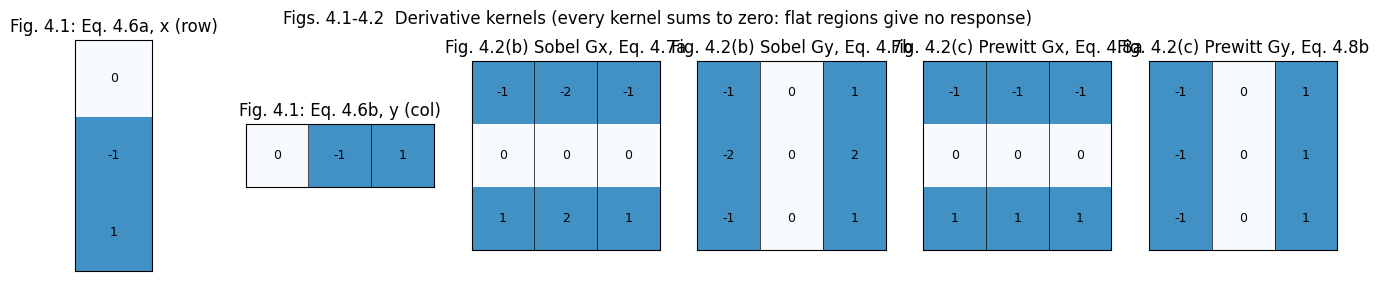

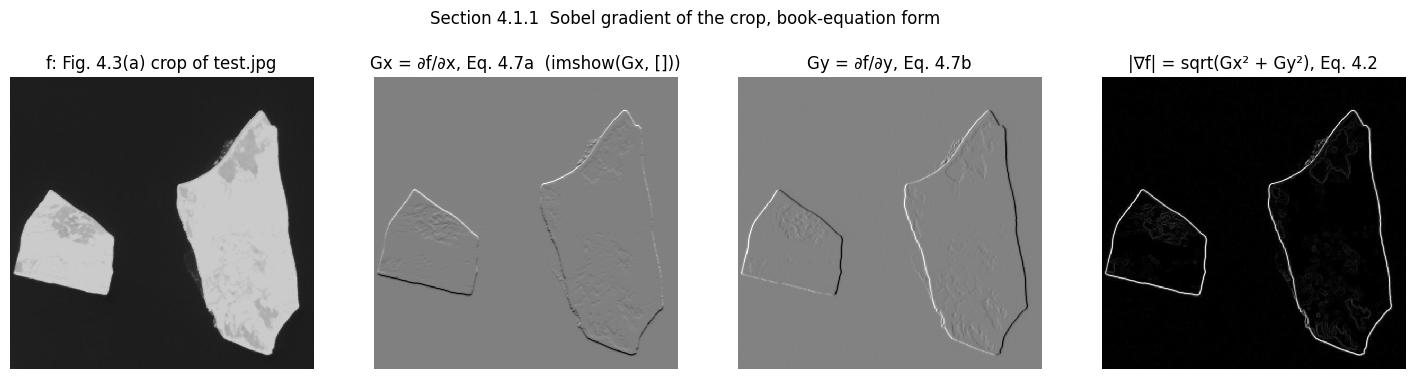

MATLAB's edge uses fspecial('sobel')/8 = -(Fig. 4.2(b) Gx)/8:  max|Gx_book + 8 gh| = 0.0e+00, max|Gy_book + 8 gv| = 0.0e+00
fspecial('sobel') = [[1.0, 2.0, 1.0], [0.0, 0.0, 0.0], [-1.0, -2.0, -1.0]]
at the strongest edge pixel: |∇f| = 2.1335 (Eq. 4.2), Gx²+Gy² = 4.5520 (Eq. 4.4), |Gx|+|Gy| = 2.9688 (Eq. 4.5), θ = arctan(Gx/Gy) = 34.7° (Eq. 4.3)
text rule |∇f|/8 > T vs edge(..., 'nothinning'): 0 px differ; 7013 edge px before thinning -> 1736 after MATLAB's thinning


In [5]:
from seaice.ch04_ice_edge_detection import FORWARD_KERNELS, SOBEL_KERNELS, PREWITT_KERNELS, \
    gradient_operator, gradient_magnitude, gradient_direction, threshold_gradient
from seaice.core.edges import edge
from seaice.core.filters import fspecial

# --- Figs. 4.1-4.2: the kernels as printed (correlation form, x = row) ---------------------------------------------
kernels = [("Fig. 4.1: Eq. 4.6a, x (row)", FORWARD_KERNELS["x"]), ("Fig. 4.1: Eq. 4.6b, y (col)", FORWARD_KERNELS["y"]),
           ("Fig. 4.2(b) Sobel Gx, Eq. 4.7a", SOBEL_KERNELS["x"]), ("Fig. 4.2(b) Sobel Gy, Eq. 4.7b", SOBEL_KERNELS["y"]),
           ("Fig. 4.2(c) Prewitt Gx, Eq. 4.8a", PREWITT_KERNELS["x"]), ("Fig. 4.2(c) Prewitt Gy, Eq. 4.8b", PREWITT_KERNELS["y"])]
fig, axes = plt.subplots(1, 6, figsize=(17, 3))
for ax, (title, k) in zip(axes, kernels):
    show_matrix(ax, k, title=title, fontsize=9)
fig.suptitle("Figs. 4.1-4.2  Derivative kernels (every kernel sums to zero: flat regions give no response)")
plt.show()

# --- Eqs. 4.1-4.5 on the crop --------------------------------------------------------------------------------------
im = crop.astype(np.float64) / 256.0                  # derivative.m line 5: im = double(im)/256
Gx, Gy = gradient_operator(im, "sobel")               # Eq. 4.7 (unscaled, book sign, replicate padding)
mag = gradient_magnitude(Gx, Gy, "l2")                # Eq. 4.2
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
imshow_matlab(axes[0], crop, title=f"f: {CROP_LABEL}")
imshow_matlab(axes[1], Gx, autoscale=True, title="Gx = ∂f/∂x, Eq. 4.7a  (imshow(Gx, []))")
imshow_matlab(axes[2], Gy, autoscale=True, title="Gy = ∂f/∂y, Eq. 4.7b")
imshow_matlab(axes[3], mag, autoscale=True, title="|∇f| = sqrt(Gx² + Gy²), Eq. 4.2")
fig.suptitle("Section 4.1.1  Sobel gradient of the crop, book-equation form")
plt.show()

res = edge(im, "sobel", 0.05)                         # MATLAB [BW, thresh, gv, gh] = edge(im, 'sobel', 0.05)
p = mag.argmax()
print(f"MATLAB's edge uses fspecial('sobel')/8 = -(Fig. 4.2(b) Gx)/8:  max|Gx_book + 8 gh| = {np.abs(Gx + 8 * res.gh).max():.1e}, "
      f"max|Gy_book + 8 gv| = {np.abs(Gy + 8 * res.gv).max():.1e}")
print("fspecial('sobel') =", fspecial("sobel").tolist())
print(f"at the strongest edge pixel: |∇f| = {mag.flat[p]:.4f} (Eq. 4.2), Gx²+Gy² = {gradient_magnitude(Gx, Gy, 'squared').flat[p]:.4f} (Eq. 4.4), "
      f"|Gx|+|Gy| = {gradient_magnitude(Gx, Gy, 'l1').flat[p]:.4f} (Eq. 4.5), θ = arctan(Gx/Gy) = {np.degrees(gradient_direction(Gx, Gy)).flat[p]:.1f}° (Eq. 4.3)")
bw_eq = threshold_gradient(mag / 8.0, 0.05)           # the text's rule |∇f| > T on the /8-scaled magnitude
bw_nothin = edge(im, "sobel", 0.05, thinning=False).bw
print(f"text rule |∇f|/8 > T vs edge(..., 'nothinning'): {int((bw_eq != bw_nothin).sum())} px differ; "
      f"{int(bw_nothin.sum())} edge px before thinning -> {int(res.bw.sum())} after MATLAB's thinning")

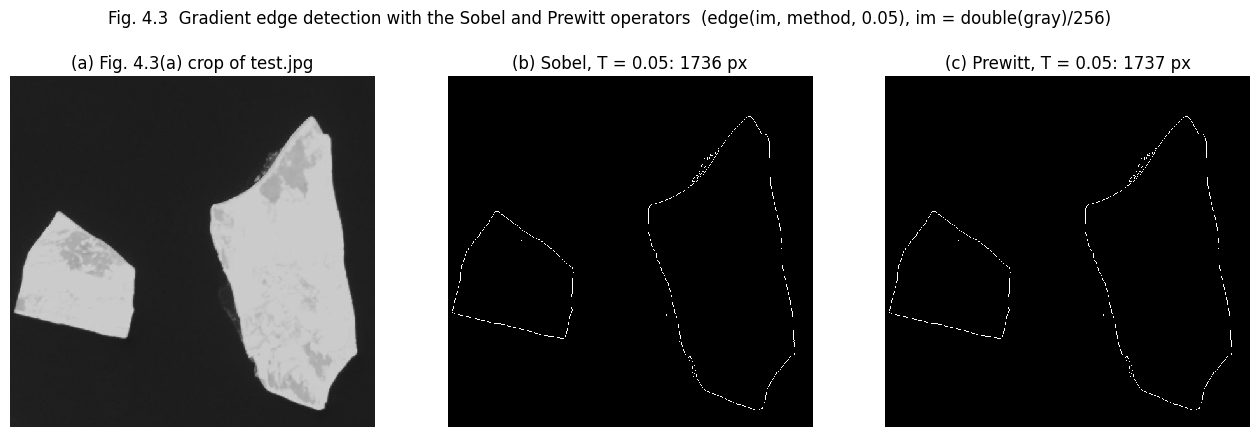

Sobel T = 0.05: 1736 edge px  [MATLAB R2025a on the book image: 1736 px, 0 differ];  Prewitt T = 0.05: 1737 px  [MATLAB R2025a on the book image: 1737 px, 0 differ]
Sobel / Prewitt overlap: 1707 px common = 98.3 % of the Sobel edges  (p. 63: 'similar results')


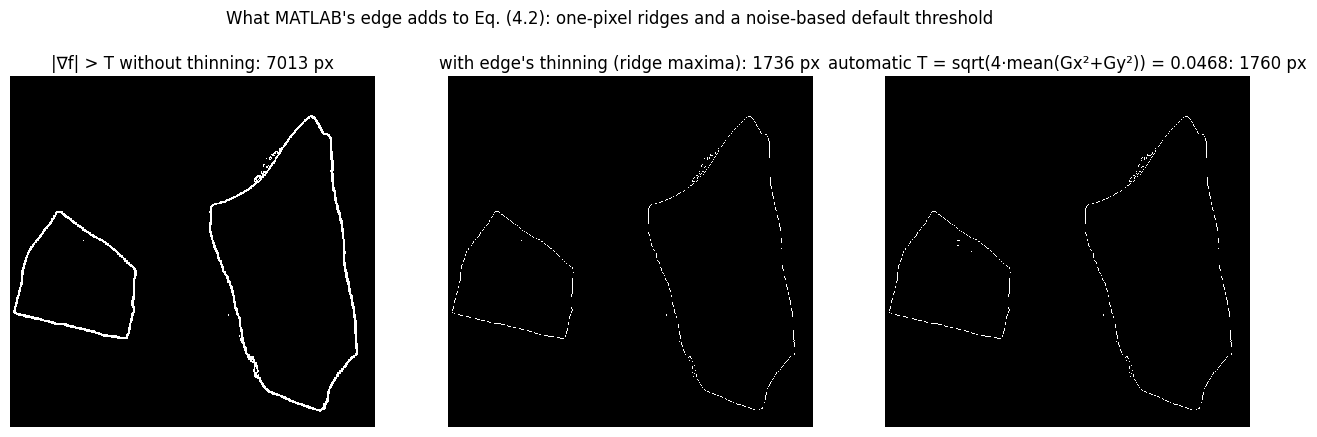

In [6]:
from seaice.ch04_ice_edge_detection import sobel_edges_script

T = BOOK_PARAMS["sobel_T"]                            # 0.05 (p. 63)
sob = sobel_edges_script(crop, T, "sobel")            # derivative.m, lines 5-7, on the crop
pre = sobel_edges_script(crop, T, "prewitt")          # text-only variant (Fig. 4.3(c))
auto = sobel_edges_script(crop, None, "sobel")        # edge(im, 'sobel') with MATLAB's automatic threshold
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], crop, title=f"(a) {CROP_LABEL}")
imshow_matlab(axes[1], sob["bw"], title=f"(b) Sobel, T = {T}: {sob['n_edge']} px")
imshow_matlab(axes[2], pre["bw"], title=f"(c) Prewitt, T = {T}: {pre['n_edge']} px")
fig.suptitle("Fig. 4.3  Gradient edge detection with the Sobel and Prewitt operators  (edge(im, method, 0.05), im = double(gray)/256)")
plt.show()
print(f"Sobel T = {T}: {sob['n_edge']} edge px{matlab_ref('1736 px, 0 differ')};  Prewitt T = {T}: {pre['n_edge']} px{matlab_ref('1737 px, 0 differ')}")
agree = int((sob["bw"] & pre["bw"]).sum())
print(f"Sobel / Prewitt overlap: {agree} px common = {100 * agree / max(sob['n_edge'], 1):.1f} % of the Sobel edges  (p. 63: 'similar results')")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], bw_nothin, title=f"|∇f| > T without thinning: {int(bw_nothin.sum())} px")
imshow_matlab(axes[1], sob["bw"], title=f"with edge's thinning (ridge maxima): {sob['n_edge']} px")
imshow_matlab(axes[2], auto["bw"], title=f"automatic T = sqrt(4·mean(Gx²+Gy²)) = {auto['thresh']:.4f}: {auto['n_edge']} px")
fig.suptitle("What MATLAB's edge adds to Eq. (4.2): one-pixel ridges and a noise-based default threshold")
plt.show()

Both operators trace the outer contours of the two floes as closed one-pixel curves and pick up the same texture
inside; they differ in about 1–2 % of the pixels, which is the book's "similar results". Without thinning the edges
would be several pixels wide (every pixel on the ramp exceeds $T$); MATLAB keeps only the ridge of the magnitude.

## 4.1.2 Laplacian (pp. 63–66) — Eqs. (4.9)–(4.15), Figs. 4.4–4.6 (text only; `edge(…, 'log')` for Fig. 4.6)

The second derivative crosses zero at an edge. The Laplacian $\nabla^2 f = \partial^2 f/\partial x^2 + \partial^2
f/\partial y^2$ (Eq. 4.9) is discretised by differencing Eq. (4.6a) once more — $f(x+2, y) - 2f(x+1, y) + f(x, y)$
(Eq. 4.10), re-centred to $f(x+1, y) + f(x-1, y) - 2f(x, y)$ (Eq. 4.11) and likewise in $y$ (Eq. 4.12) — giving

$$\nabla^2 f(x, y) = f(x-1, y) + f(x+1, y) + f(x, y-1) + f(x, y+1) - 4 f(x, y) \quad (4.13),$$

the 4-neighbour kernel of Fig. 4.4(a); Fig. 4.4(b) adds the diagonals (centre $-8$). The response is zero where the
intensity is constant or linear and changes sign where the rate of change bends, so a simple zero-crossing detector
(p. 64) takes, in a $3 \times 3$ window, the maximum of the positive and the minimum of the negative responses and
declares an edge where their difference exceeds $T$. Because a second derivative amplifies noise, the image is first
smoothed with the Gaussian $G_\sigma(x, y) = \frac{1}{2\pi\sigma^2} e^{-(x^2+y^2)/2\sigma^2}$ (Eq. 4.14; truncated at
$3\sigma$, which covers > 99 %), and the two steps combine into the **Laplacian of Gaussian**

$$\nabla^2 G_\sigma(x, y) = \frac{1}{2\pi\sigma^2} \cdot \frac{x^2 + y^2 - 2\sigma^2}{\sigma^4}\, e^{-(x^2+y^2)/2\sigma^2} \quad (4.15).$$

Fig. 4.5 prints the $5 \times 5$, $\sigma = 1$ Gaussian (0.0030 … 0.1621) and LoG (0.0239 … $-$0.3182) kernels — these
are exactly `fspecial('gaussian', 5, 1)` (unit sum) and `fspecial('log', 5, 1)` (unit-sum Gaussian times
$(x^2+y^2-2\sigma^2)/\sigma^4$, then mean-subtracted so the kernel sums to zero), not a raw sampling of Eq. (4.15).
Fig. 4.6 is `edge(crop, 'log', 0.005, 2)`: a $13 \times 13$ kernel ($2\lceil 3\sigma \rceil + 1$), $\sigma = 2$,
$T = 0.005$.

> **The LoG threshold applies to the *jump*, not to $|\nabla^2 f|$.** The text only says "threshold $T = 0.005$";
> MATLAB's rule (ported in `log_zero_crossings`) marks the negative pixel of every sign change with a right / lower /
> left / upper neighbour whose difference $|b(p) - b(q)|$ exceeds $T$ (pixels with $b = 0$ need opposite-sign
> neighbours differing by more than $2T$). This is what makes flat synthetic patches noise-sensitive: there the
> response is rounding noise of order $10^{-17}$ whose *sign* decides — MATLAB itself flags 14 spurious pixels on a
> constant image at its automatic $T$, and our port and MATLAB disagree on such pixels (parity `near` on
> piecewise-constant inputs, `exact` on every real image tested).

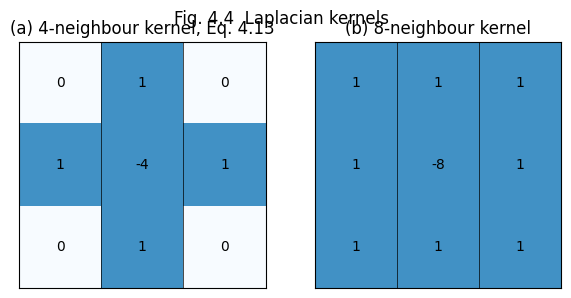

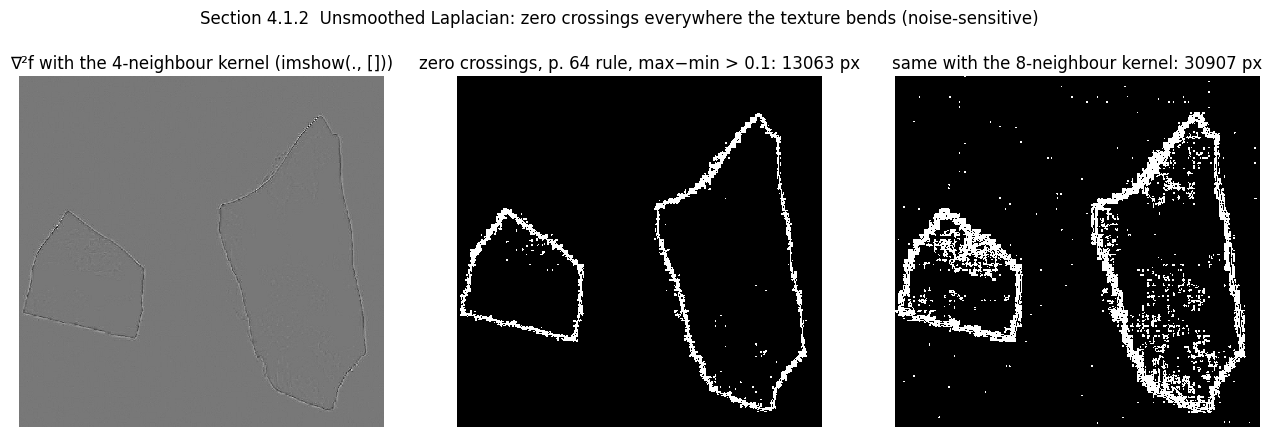

Laplacian range on the crop: 4-nb -0.691 .. 0.781, 8-nb -1.184 .. 1.395; fspecial('laplacian', 0) == Fig. 4.4(a): True


In [7]:
from seaice.ch04_ice_edge_detection import LAPLACIAN_KERNELS, laplacian, laplacian_zero_crossings

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
show_matrix(axes[0], LAPLACIAN_KERNELS[4], title="(a) 4-neighbour kernel, Eq. 4.13", fontsize=10)
show_matrix(axes[1], LAPLACIAN_KERNELS[8], title="(b) 8-neighbour kernel", fontsize=10)
fig.suptitle("Fig. 4.4  Laplacian kernels")
plt.show()

T_zc = 0.1                                            # our choice for the text's 3x3 rule (the book gives none)
lap4, lap8 = laplacian(im, 4), laplacian(im, 8)       # Eq. 4.13 on the /256 image (replicate padding)
zc4, zc8 = laplacian_zero_crossings(lap4, T_zc), laplacian_zero_crossings(lap8, T_zc)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], lap4, autoscale=True, title="∇²f with the 4-neighbour kernel (imshow(., []))")
imshow_matlab(axes[1], zc4, title=f"zero crossings, p. 64 rule, max−min > {T_zc}: {int(zc4.sum())} px")
imshow_matlab(axes[2], zc8, title=f"same with the 8-neighbour kernel: {int(zc8.sum())} px")
fig.suptitle("Section 4.1.2  Unsmoothed Laplacian: zero crossings everywhere the texture bends (noise-sensitive)")
plt.show()
print(f"Laplacian range on the crop: 4-nb {lap4.min():.3f} .. {lap4.max():.3f}, 8-nb {lap8.min():.3f} .. {lap8.max():.3f}; "
      f"fspecial('laplacian', 0) == Fig. 4.4(a): {np.array_equal(fspecial('laplacian', 0), LAPLACIAN_KERNELS[4])}")

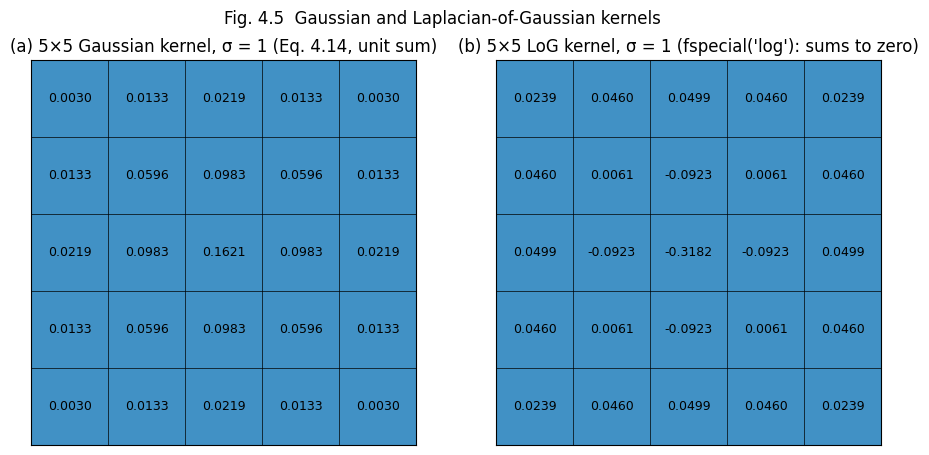

Fig. 4.5(a) printed values vs gaussian_kernel: max deviation 3.8e-05 (4-dp rounding); sum = 1.000000
Fig. 4.5(b) printed values vs log_kernel('matlab'): max deviation 4.9e-05; sum = 9.0e-17
Eq. 4.15 sampled literally: centre = -1/π = -0.3183, sum = -0.1486 (not zero) -> the printed -0.3182 is the mean-subtracted fspecial form
'3σ covers more than 99 %': unnormalised 7×7 σ = 1 Gaussian sums to 0.9995
Fig. 4.6 kernel fspecial('log', 13, 2): (13, 13), centre -0.01990, sum -6.9e-18


In [8]:
from seaice.ch04_ice_edge_detection import gaussian_kernel, log_kernel

g5 = gaussian_kernel(5, 1.0)                          # Eq. 4.14 sampled and normalised to unit sum (= fspecial('gaussian', 5, 1))
l5 = log_kernel(5, 1.0)                               # 'matlab' mode = fspecial('log', 5, 1) = Fig. 4.5(b)
l5_an = log_kernel(5, 1.0, mode="analytic")           # Eq. 4.15 sampled literally
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_matrix(axes[0], g5, fmt="{:.4f}", title="(a) 5×5 Gaussian kernel, σ = 1 (Eq. 4.14, unit sum)", fontsize=9)
show_matrix(axes[1], l5, fmt="{:.4f}", title="(b) 5×5 LoG kernel, σ = 1 (fspecial('log'): sums to zero)", fontsize=9)
fig.suptitle("Fig. 4.5  Gaussian and Laplacian-of-Gaussian kernels")
plt.show()

# the values printed in the book (one quadrant; the kernels are symmetric) -> 1-line glue to unfold them
q_g = np.array([[0.0030, 0.0133, 0.0219], [0.0133, 0.0596, 0.0983], [0.0219, 0.0983, 0.1621]])
q_l = np.array([[0.0239, 0.0460, 0.0499], [0.0460, 0.0061, -0.0923], [0.0499, -0.0923, -0.3182]])
unfold = lambda q: (lambda top: np.vstack([top, top[-2::-1]]))(np.hstack([q, q[:, -2::-1]]))
print(f"Fig. 4.5(a) printed values vs gaussian_kernel: max deviation {np.abs(unfold(q_g) - g5).max():.1e} (4-dp rounding); sum = {g5.sum():.6f}")
print(f"Fig. 4.5(b) printed values vs log_kernel('matlab'): max deviation {np.abs(unfold(q_l) - l5).max():.1e}; sum = {l5.sum():.1e}")
print(f"Eq. 4.15 sampled literally: centre = -1/π = {l5_an[2, 2]:.4f}, sum = {l5_an.sum():.4f} (not zero) -> the printed -0.3182 is the mean-subtracted fspecial form")
print(f"'3σ covers more than 99 %': unnormalised 7×7 σ = 1 Gaussian sums to {gaussian_kernel(7, 1.0, normalize=False).sum():.4f}")
h13 = fspecial("log", 13, 2.0)                        # the Fig. 4.6 kernel: 2*ceil(3*2)+1 = 13
print(f"Fig. 4.6 kernel fspecial('log', 13, 2): {h13.shape}, centre {h13[6, 6]:.5f}, sum {h13.sum():.1e}")

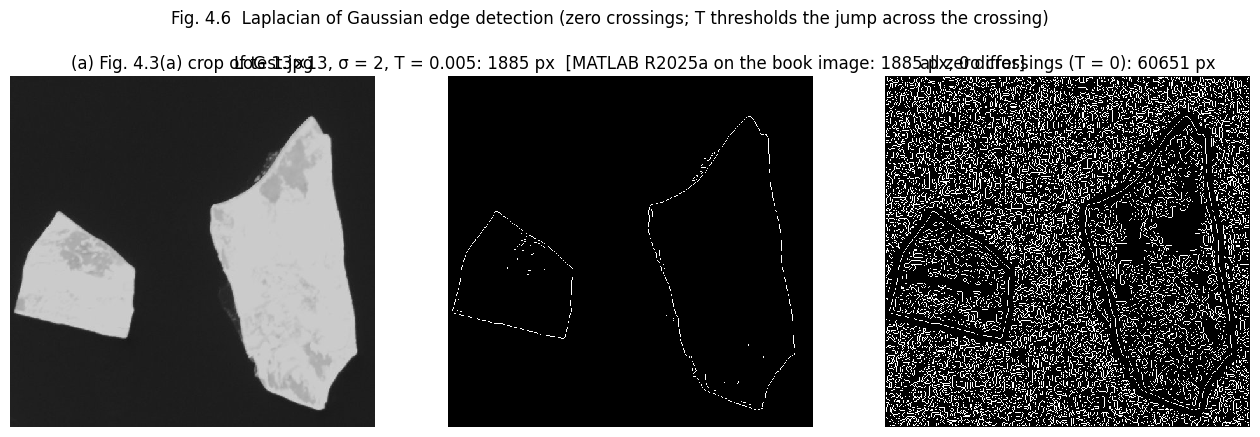

LoG edge pixels: T = 0 -> 60651, T = 0.005 -> 1885, automatic T = 0.00122 -> 5791; Sobel T = 0.05 gave 1736 (§4.3 (b): the second derivative is noisier)
noise sensitivity on synthetic flat patches (our port): constant image -> 0 px at the automatic T = 1.9e-17; step image, T = 0.001 -> 44 px = 2 columns for a single-column step (the extra crossings sit where |b| ~ 1e-17 is rounding noise; on the verification fixtures MATLAB itself flagged 14 such pixels on a constant image and one column of a step where the port flags two)


In [9]:
sig, T_log = BOOK_PARAMS["log_sigma"], BOOK_PARAMS["log_T"]         # σ = 2, T = 0.005 (pp. 65-66)
log = sobel_edges_script(crop, T_log, "log", sigma=sig)              # edge(im, 'log', 0.005, 2)
log_all = sobel_edges_script(crop, 0.0, "log", sigma=sig)            # every sign change (T = 0)
log_auto = sobel_edges_script(crop, None, "log", sigma=sig)          # automatic T = 0.75·mean|b|
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], crop, title=f"(a) {CROP_LABEL}")
imshow_matlab(axes[1], log["bw"], title=f"LoG 13×13, σ = {sig:g}, T = {T_log}: {log['n_edge']} px{matlab_ref('1885 px, 0 differ')}")
imshow_matlab(axes[2], log_all["bw"], title=f"all zero crossings (T = 0): {log_all['n_edge']} px")
fig.suptitle("Fig. 4.6  Laplacian of Gaussian edge detection (zero crossings; T thresholds the jump across the crossing)")
plt.show()
print(f"LoG edge pixels: T = 0 -> {log_all['n_edge']}, T = {T_log} -> {log['n_edge']}, automatic T = {log_auto['thresh']:.5f} -> {log_auto['n_edge']}; "
      f"Sobel T = 0.05 gave {sob['n_edge']} (§4.3 (b): the second derivative is noisier)")
flat = np.full((24, 24), 0.5); step = flat.copy(); step[:, 12:] = 0.8                # synthetic: a constant patch and a step
e_flat, e_step = edge(flat, "log", None, sigma=1.0), edge(step, "log", 0.001, sigma=1.0)
print(f"noise sensitivity on synthetic flat patches (our port): constant image -> {int(e_flat.bw.sum())} px at the automatic T = {e_flat.thresh:.1e}; "
      f"step image, T = 0.001 -> {int(e_step.bw.sum())} px = {int(e_step.bw.any(axis=0).sum())} columns for a single-column step "
      "(the extra crossings sit where |b| ~ 1e-17 is rounding noise; on the verification fixtures MATLAB itself flagged 14 such pixels on a constant "
      "image and one column of a step where the port flags two)")

The LoG map closes the floe contours like Sobel but is thicker and speckled inside the bright floe: every bend of the
texture is a zero crossing, and $T$ only removes the weakest ones. This is the book's point (b) in §4.3 — the second
derivative is too noise-sensitive to be used alone.

## 4.2 Morphological edge detection — structuring elements (pp. 66–67), Fig. 4.7 (text only)

Mathematical morphology analyses shapes with set operations between the image and a small **structuring element**
(SE): a 0/1 matrix with an origin, translated to every pixel and compared with the pixels underneath. The book uses
only *flat, symmetric* SEs with the origin at the geometric centre — Fig. 4.7: a $3 \times 3$ square, a $3 \times 5$
rectangle, a "disk with 5-pixel radius" and a diamond reaching 5 pixels from the origin. The printed disk is the
$9 \times 9$, 69-pixel matrix of MATLAB's `strel('disk', 5)`, which is **not** a Euclidean disk ($11 \times 11$, 81
pixels) but Adams' periodic-line approximation (default `n = 4`, an octagon); `morphology.m` writes `strel('dis', 7)`,
MATLAB's unambiguous-prefix matching for `'disk'`, giving a $13 \times 13$ / 157-pixel SE. `seaice.core.morphology.strel`
reproduces all of MATLAB's neighbourhoods (116 verified identical) and `disk_decomposition` the sequence of lines MATLAB
erodes with.

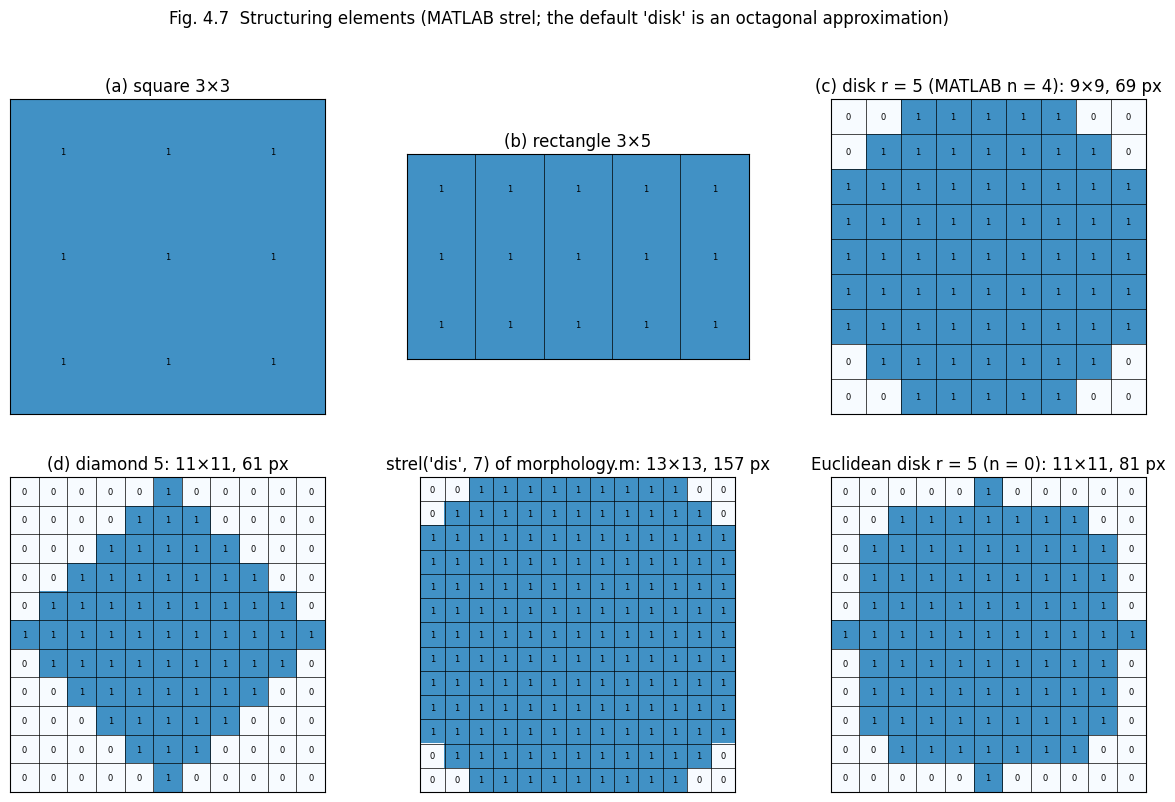

(a) square 3×3                                   -> 3x3, 9 px, origin (1, 1) (0-based)
(b) rectangle 3×5                                -> 3x5, 15 px, origin (1, 2) (0-based)
(c) disk r = 5 (MATLAB n = 4): 9×9, 69 px        -> 9x9, 69 px, origin (4, 4) (0-based)
(d) diamond 5: 11×11, 61 px                      -> 11x11, 61 px, origin (5, 5) (0-based)
strel('dis', 7) of morphology.m: 13×13, 157 px   -> 13x13, 157 px, origin (6, 6) (0-based)
Euclidean disk r = 5 (n = 0): 11×11, 81 px       -> 11x11, 81 px, origin (5, 5) (0-based)
decompose(strel('disk', 7)): 6 line SEs of sizes [(5, 1), (3, 3), (1, 5), (3, 3), (1, 5), (5, 1)] -> their Minkowski sum is the 13×13 octagon
strel('disk', 15) used by the book figures: 29x29, 697 px
strel('disk',  5) used by the book figures: 9x9, 69 px
strel('disk', 16) used by the book figures: 31x31, 817 px


In [10]:
from seaice.core.morphology import strel, disk_decomposition, se_origin

ses = [("(a) square 3×3", strel("square", 3)), ("(b) rectangle 3×5", strel("rectangle", [3, 5])),
       ("(c) disk r = 5 (MATLAB n = 4): 9×9, 69 px", strel("disk", 5)), ("(d) diamond 5: 11×11, 61 px", strel("diamond", 5)),
       ("strel('dis', 7) of morphology.m: 13×13, 157 px", strel("dis", 7)), ("Euclidean disk r = 5 (n = 0): 11×11, 81 px", strel("disk", 5, 0))]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (title, se) in zip(axes.ravel(), ses):
    show_matrix(ax, se.astype(int), title=title, fontsize=6)
fig.suptitle("Fig. 4.7  Structuring elements (MATLAB strel; the default 'disk' is an octagonal approximation)")
plt.show()
for title, se in ses:
    print(f"{title:48s} -> {se.shape[0]}x{se.shape[1]}, {int(se.sum())} px, origin {se_origin(se)} (0-based)")
seq = disk_decomposition(7)
print(f"decompose(strel('disk', 7)): {len(seq)} line SEs of sizes {[s.shape for s in seq]} -> their Minkowski sum is the 13×13 octagon")
for r in (BOOK_PARAMS["disk_r_figs"], BOOK_PARAMS["disk_r_thin"], BOOK_PARAMS["disk_r_thick"]):
    se = strel("disk", r)
    print(f"strel('disk', {r:2d}) used by the book figures: {se.shape[0]}x{se.shape[1]}, {int(se.sum())} px")

## 4.2.1 Erosion and dilation (pp. 67–71) — Eqs. (4.16)–(4.21), Figs. 4.8–4.10; `ch4/morphology.m` lines 10–16, 31–32

For binary sets $A$ (object pixels) and $B$ (SE) the **erosion** keeps the origin positions where the translated SE
$(B)_z = \{b + z \mid b \in B\}$ (Eq. 4.17) fits entirely inside the object,

$$A \ominus B = \{z \mid (B)_z \subseteq A\} \quad (4.16), \qquad A \oplus B = \{z \mid (\hat B)_z \cap A \neq \emptyset\} \quad (4.18),$$

and the **dilation** keeps the positions where the *reflected* SE $\hat B = \{w \mid -w \in B\}$ (Eq. 4.19) touches
the object at all; erosion shrinks, dilation grows, by an amount set by the SE. Fig. 4.8 walks through both on an
$11 \times 15$ rectangle with a cross SE ($B = \hat B$): the $3 \times 7$ object erodes to a single row of 5 pixels and
dilates to $5 \times 9$ with clipped corners. For a grayscale image $f$ and a flat SE $b$ the same operations become a
moving minimum and a moving (reflected) maximum,

$$[f \ominus b](x, y) = \min_{(s,t) \in b} f(x+s, y+t) \quad (4.20), \qquad [f \oplus b](x, y) = \max_{(s,t) \in b} f(x-s, y-t) \quad (4.21).$$

Figs. 4.9 and 4.10 apply a 15-pixel disk to the binarised (`im2bw(im, graythresh(im))`, Chapter 3) and to the gray
crop. One rule the text leaves to MATLAB: pixels outside the image count as 1 / $+\infty$ for erosion and 0 / $-\infty$
for dilation, so borders never create or destroy objects; `imerode` / `imdilate` follow it and are bit-exact.

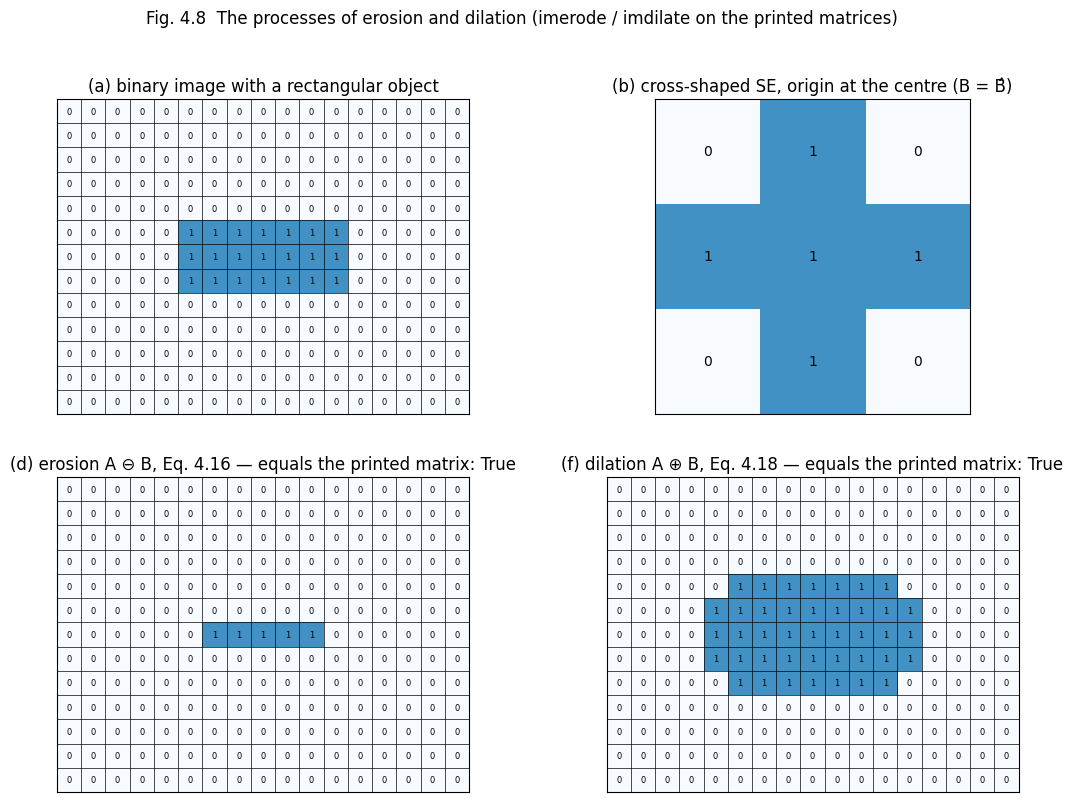

Fig. 4.8: object 21 px -> eroded 5 px (one row of 5), dilated 41 px (5×9 minus 4 corners)
border rule: imerode(all-ones, 3×3) stays all ones = True; imdilate(all-zeros, 3×3) stays all zeros = True


In [11]:
from seaice.ch04_ice_edge_detection import fig_4_8_demo, morphological_edges
from seaice.core.morphology import imerode, imdilate

d = fig_4_8_demo()                                    # the printed matrices of Fig. 4.8 (a), (b) -> imerode / imdilate
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
show_matrix(axes[0, 0], d["image"].astype(int), title="(a) binary image with a rectangular object", fontsize=6)
show_matrix(axes[0, 1], d["se"].astype(int), title="(b) cross-shaped SE, origin at the centre (B = B̂)", fontsize=10)
show_matrix(axes[1, 0], d["eroded"].astype(int), title=f"(d) erosion A ⊖ B, Eq. 4.16 — equals the printed matrix: {d['erosion_matches']}", fontsize=6)
show_matrix(axes[1, 1], d["dilated"].astype(int), title=f"(f) dilation A ⊕ B, Eq. 4.18 — equals the printed matrix: {d['dilation_matches']}", fontsize=6)
fig.suptitle("Fig. 4.8  The processes of erosion and dilation (imerode / imdilate on the printed matrices)")
plt.show()
print(f"Fig. 4.8: object {int(d['image'].sum())} px -> eroded {int(d['eroded'].sum())} px (one row of 5), dilated {int(d['dilated'].sum())} px (5×9 minus 4 corners)")
ones = np.ones((6, 6), dtype=bool)
print(f"border rule: imerode(all-ones, 3×3) stays all ones = {bool(imerode(ones, strel('square', 3)).all())}; "
      f"imdilate(all-zeros, 3×3) stays all zeros = {bool(~imdilate(~ones, strel('square', 3)).all())}")

morphology.m pipeline on the crop, disk r = 15 (29x29, 697 px): 0.05 s
graythresh: level = 0.443137 -> t* = 113, ice pixels I = 91963 (IC = 29.02 %)  [MATLAB R2025a on the book image: t* = 113, I 91 963 px]
binary: erosion J = 67634 px, dilation K = 119094 px  [MATLAB R2025a on the book image: J 67 634 / K 119 094, 0 px differ]


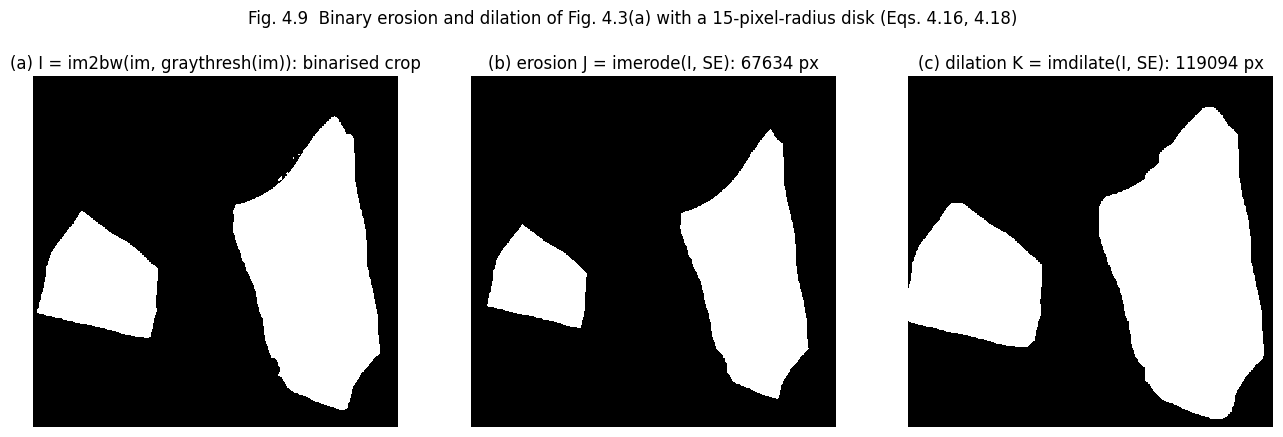

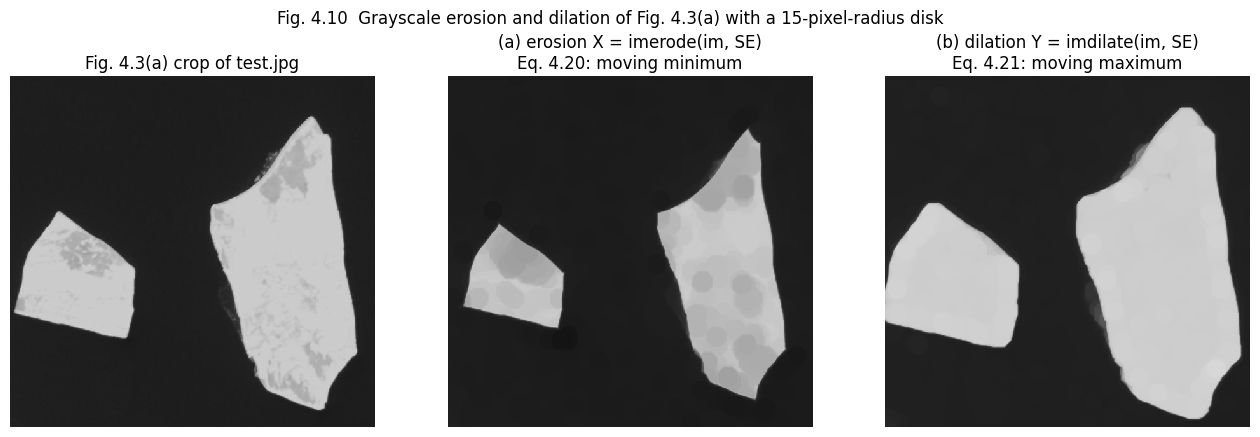

gray erosion mean 61.8 <= image mean 79.1 <= dilation mean 97.2  (anti-extensive / extensive)


In [12]:
R = BOOK_PARAMS["disk_r_figs"]                        # 15 (pp. 69, 71, 78-79)
t0 = time.perf_counter()
mo15 = morphological_edges(crop, radius=R)            # morphology.m on the crop with strel('disk', 15): 12 arrays
print(f"morphology.m pipeline on the crop, disk r = {R} ({mo15['SE'].shape[0]}x{mo15['SE'].shape[1]}, {int(mo15['SE'].sum())} px): {time.perf_counter() - t0:.2f} s")
print(f"graythresh: level = {mo15['level']:.6f} -> t* = {mo15['threshold']:g}, ice pixels I = {int(mo15['I'].sum())} (IC = {100 * mo15['ic']:.2f} %)"
      f"{matlab_ref('t* = 113, I 91 963 px')}")
print(f"binary: erosion J = {int(mo15['J'].sum())} px, dilation K = {int(mo15['K'].sum())} px{matlab_ref('J 67 634 / K 119 094, 0 px differ')}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], mo15["I"], title="(a) I = im2bw(im, graythresh(im)): binarised crop")
imshow_matlab(axes[1], mo15["J"], title=f"(b) erosion J = imerode(I, SE): {int(mo15['J'].sum())} px")
imshow_matlab(axes[2], mo15["K"], title=f"(c) dilation K = imdilate(I, SE): {int(mo15['K'].sum())} px")
fig.suptitle(f"Fig. 4.9  Binary erosion and dilation of Fig. 4.3(a) with a {R}-pixel-radius disk (Eqs. 4.16, 4.18)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], crop, title=f"{CROP_LABEL}")
imshow_matlab(axes[1], mo15["X"], title="(a) erosion X = imerode(im, SE)\nEq. 4.20: moving minimum")
imshow_matlab(axes[2], mo15["Y"], title="(b) dilation Y = imdilate(im, SE)\nEq. 4.21: moving maximum")
fig.suptitle(f"Fig. 4.10  Grayscale erosion and dilation of Fig. 4.3(a) with a {R}-pixel-radius disk")
plt.show()
print(f"gray erosion mean {mo15['X'].mean():.1f} <= image mean {crop.mean():.1f} <= dilation mean {mo15['Y'].mean():.1f}  (anti-extensive / extensive)")

Erosion rounds the floes and eats every feature narrower than the 29-pixel disk (the thin lead between them opens
up); dilation swells them until they merge. In grayscale the erosion darkens and fills the floes with the dark
"bubbles" of the printed Fig. 4.10(a) (each local minimum grows to the size of the disk), the dilation brightens and
smooths them.

## 4.2.2 Morphological closing and opening (pp. 71–73) — Eqs. (4.22)–(4.23), Figs. 4.11–4.12 (text only)

Closing is a dilation followed by an erosion, opening the reverse, with the same SE:

$$A \bullet B = (A \oplus B) \ominus B \quad (4.22), \qquad A \circ B = (A \ominus B) \oplus B \quad (4.23).$$

On a binary image the closing fills background regions that cannot contain $B$ and the opening removes object regions
that cannot contain $B$, both preserving the shapes better than a bare dilation or erosion because the second step
undoes most of the growth or shrinkage. Seen as a surface, closing pushes the SE *down* onto the profile and records
the lowest point it reaches (Fig. 4.11: valleys narrower than $B$ are clipped — dark details vanish), opening pushes it
*up* from below (Fig. 4.12: peaks narrower than $B$ are clipped — bright details vanish). The book's curves are
sketches, so the 1-D profile here is synthetic (`synth.two_floes_profile`: two floe plateaus, a crack, a pit and a
speck); `imopen` / `imclose` are exact vs MATLAB, including `imclose`'s pre-padding of the border.

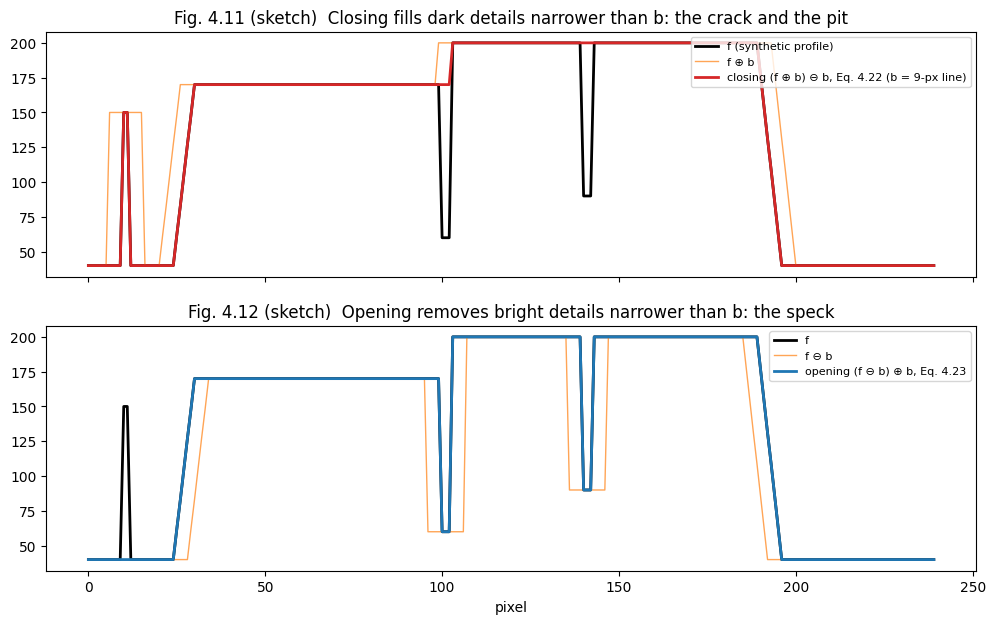

profile: crack value 60 -> closing 170; pit 90 -> 200; speck 150 -> opening 40; floe plateaus unchanged: True


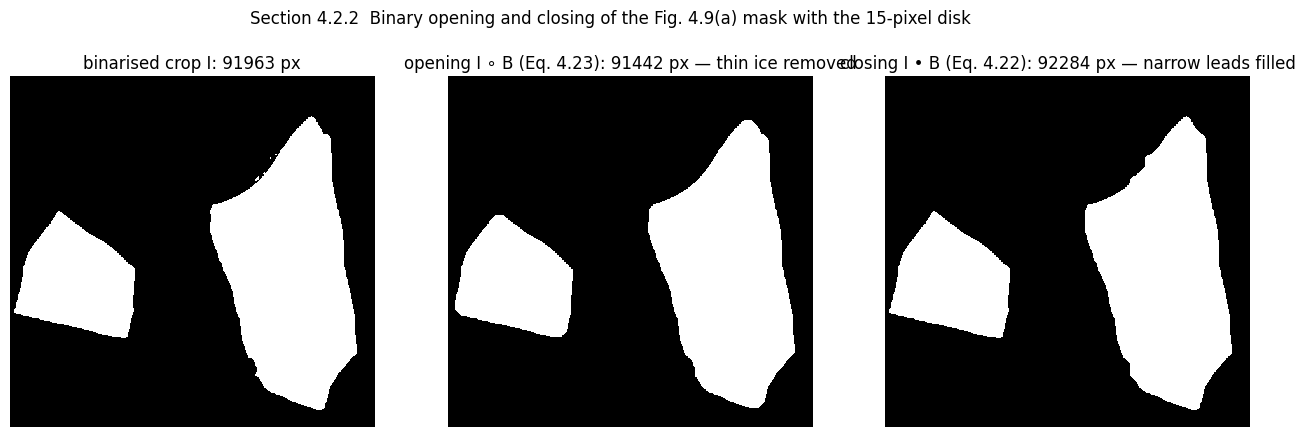

idempotence: imopen(imopen(I)) == imopen(I): True; anti-extensive/extensive: opening ⊆ I ⊆ closing: True


In [13]:
from seaice.ch04_ice_edge_detection import profile_open_close_demo
from seaice.core.morphology import imopen, imclose

oc = profile_open_close_demo()                        # 1-D profile, flat 9-px line SE: erosion, dilation, opening, closing
x = np.arange(oc["f"].size)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(x, oc["f"], "k", lw=2, label="f (synthetic profile)")
axes[0].plot(x, oc["dilation"], "C1", lw=1, alpha=0.7, label="f ⊕ b")
axes[0].plot(x, oc["closing"], "C3", lw=2, label=f"closing (f ⊕ b) ⊖ b, Eq. 4.22 (b = {int(oc['se_length'])}-px line)")
axes[0].set_title("Fig. 4.11 (sketch)  Closing fills dark details narrower than b: the crack and the pit")
axes[0].legend(loc="upper right", fontsize=8)
axes[1].plot(x, oc["f"], "k", lw=2, label="f")
axes[1].plot(x, oc["erosion"], "C1", lw=1, alpha=0.7, label="f ⊖ b")
axes[1].plot(x, oc["opening"], "C0", lw=2, label="opening (f ⊖ b) ⊕ b, Eq. 4.23")
axes[1].set_title("Fig. 4.12 (sketch)  Opening removes bright details narrower than b: the speck")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_xlabel("pixel")
plt.show()
print(f"profile: crack value {int(oc['f'][101])} -> closing {int(oc['closing'][101])}; pit {int(oc['f'][141])} -> {int(oc['closing'][141])}; "
      f"speck {int(oc['f'][10])} -> opening {int(oc['opening'][10])}; floe plateaus unchanged: {bool((oc['opening'][50] == oc['f'][50]) and (oc['closing'][50] == oc['f'][50]))}")

Io, Ic = imopen(mo15["I"], mo15["SE"]), imclose(mo15["I"], mo15["SE"])      # binary opening / closing of the crop mask, disk 15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], mo15["I"], title=f"binarised crop I: {int(mo15['I'].sum())} px")
imshow_matlab(axes[1], Io, title=f"opening I ∘ B (Eq. 4.23): {int(Io.sum())} px — thin ice removed")
imshow_matlab(axes[2], Ic, title=f"closing I • B (Eq. 4.22): {int(Ic.sum())} px — narrow leads filled")
fig.suptitle(f"Section 4.2.2  Binary opening and closing of the Fig. 4.9(a) mask with the {R}-pixel disk")
plt.show()
print(f"idempotence: imopen(imopen(I)) == imopen(I): {np.array_equal(imopen(Io, mo15['SE']), Io)}; "
      f"anti-extensive/extensive: opening ⊆ I ⊆ closing: {bool((Io <= mo15['I']).all() and (mo15['I'] <= Ic).all())}")

## 4.2.3 Morphological reconstruction (pp. 73–77) — Eqs. (4.24)–(4.38), Figs. 4.13–4.14 (text only)

Reconstruction grows a **marker** $F$ inside a **mask** $G$ ($F \subseteq G$, Eq. 4.24) with the SE $B$ defining the
connectivity. One step is the geodesic dilation $D^{(1)}_G(F) = (F \oplus B) \cap G$ (Eq. 4.25), $n$ steps are
$D^{(n)}_G = D^{(1)}_G[D^{(n-1)}_G]$ (Eq. 4.26), and iterating

$$X_k = (X_{k-1} \oplus B) \cap G, \quad X_0 = F, \quad \text{until } X_k = X_{k-1} \quad (4.27)$$

gives the reconstruction by dilation $R^D_G(F) = X_k$: exactly the connected components of $G$ that contain a marker.
Reconstruction by erosion is the dual with $(F \ominus B) \cup G$ and $G \subseteq F$ (Eqs. 4.28–4.30). For grayscale
images the intersection becomes a pointwise minimum, $D^{(1)}_g(f) = (f \oplus b) \wedge g$ with $f \le g$
(Eqs. 4.31–4.34) — the mask caps the growing marker, so the result keeps the peaks of $g$ that $f$ marks (Fig. 4.13) —
and the union a pointwise maximum, $(f \ominus b) \vee g$ with $f \ge g$ (Eqs. 4.35–4.38), which fills the valleys
(Fig. 4.14). `imreconstruct` (skimage's fast algorithm, exact vs MATLAB) and `reconstruct_iterative` (the literal
loop, returning $k$) give the same fixed point; Chapter 5 builds its watershed markers (`imimposemin`, `imfill`) on this.

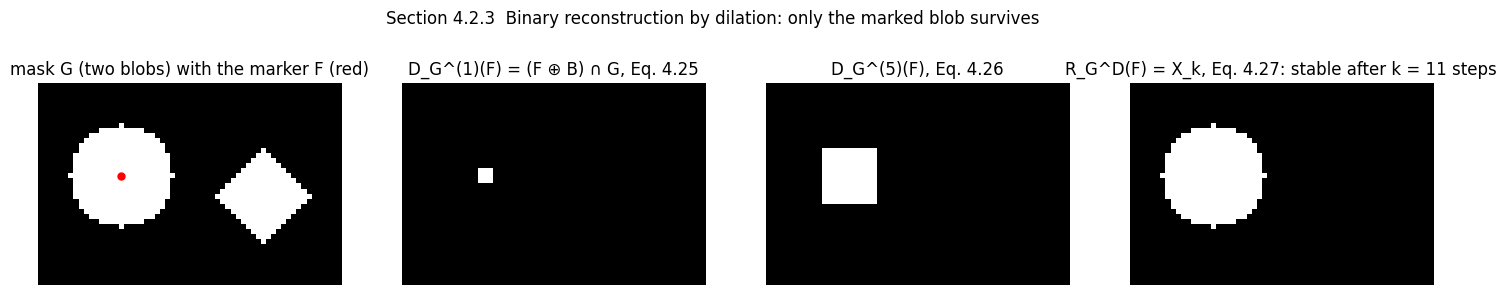

reconstruction = marked blob only: 317 px of the mask's 498; imreconstruct == literal iteration: True


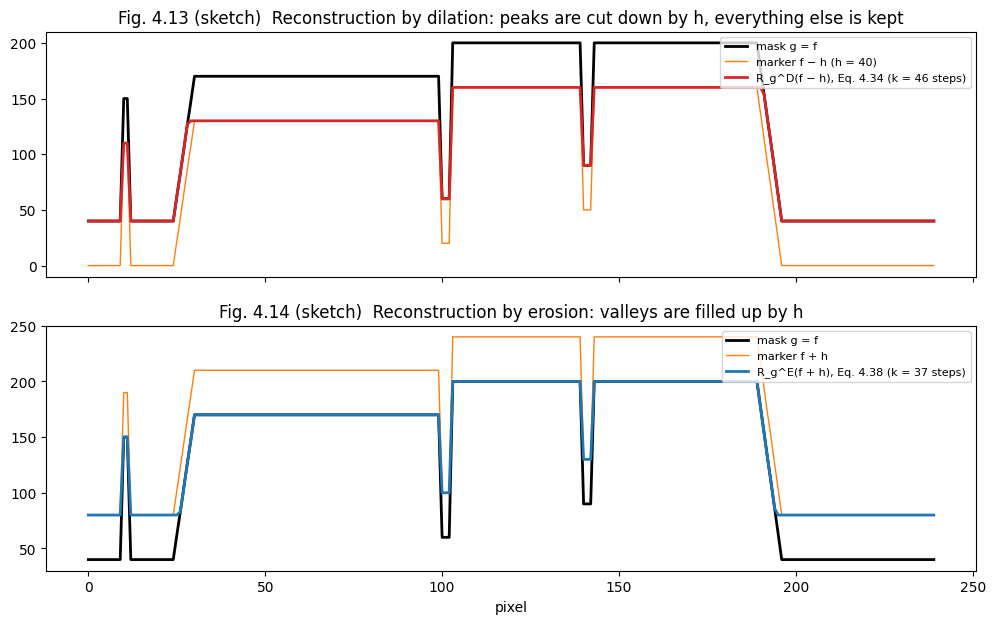

literal Eq. 4.34 / 4.38 loops equal imreconstruct / reconstruct_by_erosion: True / True; crack 60 -> 100, speck 150 -> 110 (h = 40)


In [14]:
from seaice.ch04_ice_edge_detection import profile_reconstruction_demo
from seaice.core.morphology import imreconstruct, reconstruct_iterative, geodesic_dilation

marker, mask = synth.two_blobs_with_marker()          # binary mask with two blobs, a one-pixel marker inside the first
rec = imreconstruct(marker, mask, 8)                  # R_G^D(F), Eq. 4.27 (8-connectivity = 3x3 B)
it, k = reconstruct_iterative(marker, mask, None, "dilation")
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
imshow_matlab(axes[0], mask, title="mask G (two blobs) with the marker F (red)")
mr, mc = np.nonzero(marker); axes[0].plot(mc, mr, "r.", ms=10)
imshow_matlab(axes[1], geodesic_dilation(marker, mask, None, 1), title="D_G^(1)(F) = (F ⊕ B) ∩ G, Eq. 4.25")
imshow_matlab(axes[2], geodesic_dilation(marker, mask, None, 5), title="D_G^(5)(F), Eq. 4.26")
imshow_matlab(axes[3], rec, title=f"R_G^D(F) = X_k, Eq. 4.27: stable after k = {k} steps")
fig.suptitle("Section 4.2.3  Binary reconstruction by dilation: only the marked blob survives")
plt.show()
print(f"reconstruction = marked blob only: {int(rec.sum())} px of the mask's {int(mask.sum())}; imreconstruct == literal iteration: {np.array_equal(rec, it)}")

rc = profile_reconstruction_demo()                    # grayscale, 1-D: marker f - h under mask f, marker f + h over mask f
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(x, rc["f"], "k", lw=2, label="mask g = f")
axes[0].plot(x, rc["marker_dilation"], "C1", lw=1, label=f"marker f − h (h = {rc['h']})")
axes[0].plot(x, rc["rec_dilation"], "C3", lw=2, label=f"R_g^D(f − h), Eq. 4.34 (k = {rc['k_dilation']} steps)")
axes[0].set_title("Fig. 4.13 (sketch)  Reconstruction by dilation: peaks are cut down by h, everything else is kept")
axes[0].legend(loc="upper right", fontsize=8)
axes[1].plot(x, rc["f"], "k", lw=2, label="mask g = f")
axes[1].plot(x, rc["marker_erosion"], "C1", lw=1, label="marker f + h")
axes[1].plot(x, rc["rec_erosion"], "C0", lw=2, label=f"R_g^E(f + h), Eq. 4.38 (k = {rc['k_erosion']} steps)")
axes[1].set_title("Fig. 4.14 (sketch)  Reconstruction by erosion: valleys are filled up by h")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_xlabel("pixel")
plt.show()
print(f"literal Eq. 4.34 / 4.38 loops equal imreconstruct / reconstruct_by_erosion: {rc['iterative_equals_dilation']} / {rc['iterative_equals_erosion']}; "
      f"crack {int(rc['f'][101])} -> {int(rc['rec_erosion'][101])}, speck {int(rc['f'][10])} -> {int(rc['rec_dilation'][10])} (h = {rc['h']})")

## 4.2.4 Morphological gradient (pp. 77–79) — Eqs. (4.39)–(4.42), Figs. 4.15–4.16; `ch4/morphology.m` lines 14–19, 34–36

Dilation is extensive and erosion anti-extensive, so their differences emphasise boundaries:

$$\rho = (A \oplus B) - (A \ominus B) \quad (4.39), \qquad \rho_{int} = A - (A \ominus B) \quad (4.40), \qquad \rho_{ext} = (A \oplus B) - A \quad (4.41), \qquad \rho_{int} + \rho_{ext} = \rho \quad (4.42).$$

The basic (Beucher) gradient $\rho$ approximates $|\nabla f|$ for a small SE; the internal gradient draws the edge
*inside* the object, the external one *outside*, and Eq. (4.42) shows they are "half gradients", thinner than $\rho$
— the choice depends on the objects. Figs. 4.15 (binary, the caption's "157-pixel" radius is a typo for 15) and 4.16
(grayscale) show all three on the crop. `morphology.m` computes them with `I − J`, `K − I`, `K − J` (logical minus
logical is `double` 0/1 in MATLAB) and `im − X`, `Y − im`, `Y − X` (uint8, saturating — exact here because every
difference is $\ge 0$); `morphological_gradient` reproduces both class rules. The shipped script runs on the **full
frame with r = 7**; that literal run is reproduced at the end of the cell.

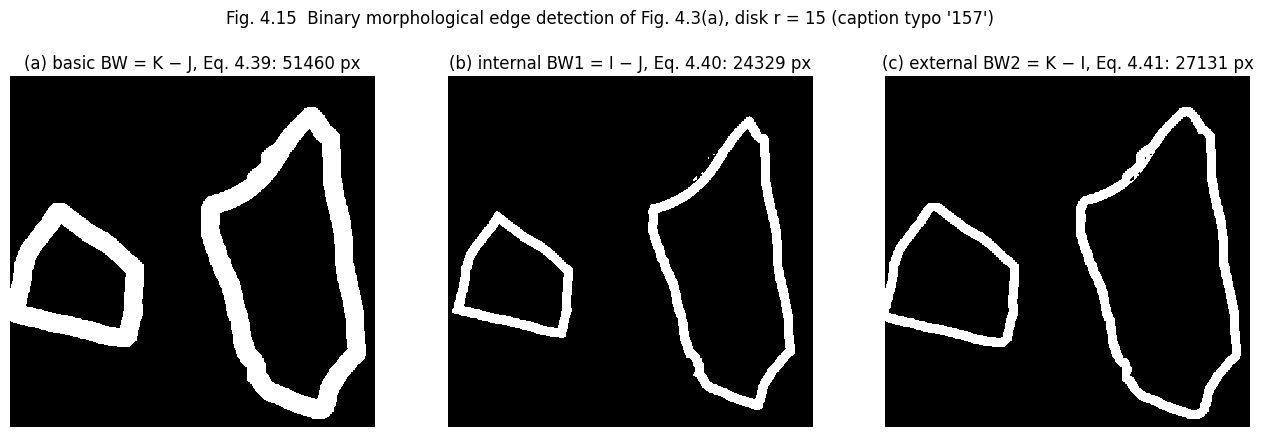

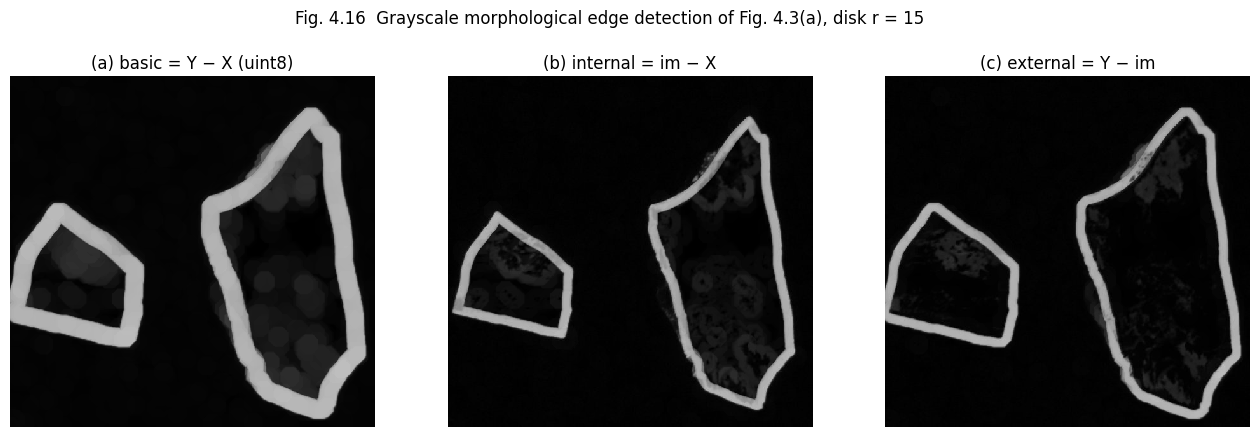

Eq. 4.42 internal + external = basic: binary True (24329 + 27131 = 51460), gray True (means 17.23 + 18.16 = 35.39)  [MATLAB R2025a on the book image: BW1 24 329 / BW2 27 131 / BW 51 460 px, all 0 differ]
MATLAB classes reproduced: BW1 is float64 0/1 (logical − logical = double), internal is uint8 (saturating minus)

morphology.m as shipped (full 2856x4290 frame, strel('dis', 7) = 13x13/157 px): 1.0 s
  t* = 113, IC = 30.98 %; J 3097387, K 4607838; BW1 698679 + BW2 811772 = BW 1510451 px; gray internal mean 12.417, external 13.258, basic 25.675  [MATLAB R2025a on the book image: t* 113, IC 30.98 %, 698 679 + 811 772 = 1 510 451, means 12.417 / 13.258 / 25.675 — all 12 arrays 0 px differ]


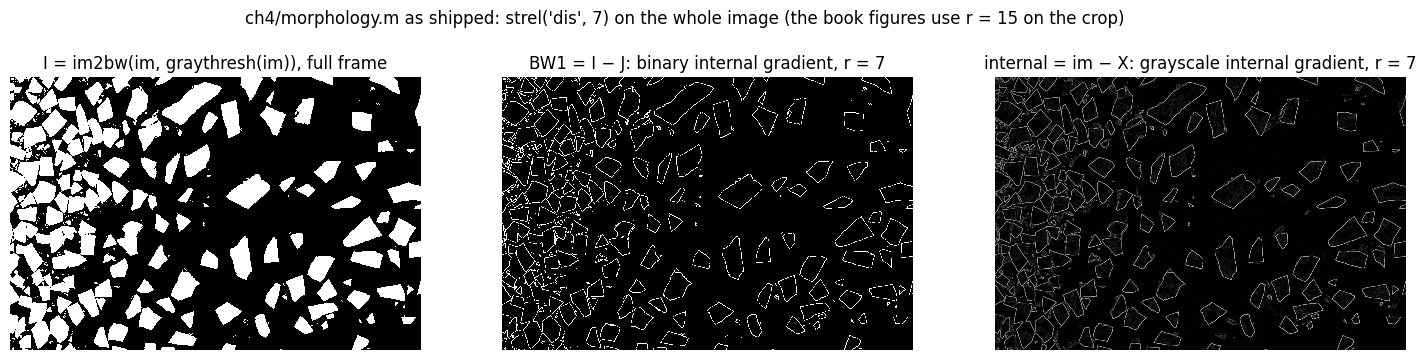

In [15]:
from seaice.ch04_ice_edge_detection import gradient_identity_check

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], mo15["BW"], title=f"(a) basic BW = K − J, Eq. 4.39: {int(mo15['BW'].sum())} px")
imshow_matlab(axes[1], mo15["BW1"], title=f"(b) internal BW1 = I − J, Eq. 4.40: {int(mo15['BW1'].sum())} px")
imshow_matlab(axes[2], mo15["BW2"], title=f"(c) external BW2 = K − I, Eq. 4.41: {int(mo15['BW2'].sum())} px")
fig.suptitle(f"Fig. 4.15  Binary morphological edge detection of Fig. 4.3(a), disk r = {R} (caption typo '157')")
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
imshow_matlab(axes[0], mo15["basic"], title="(a) basic = Y − X (uint8)")
imshow_matlab(axes[1], mo15["internal"], title="(b) internal = im − X")
imshow_matlab(axes[2], mo15["external"], title="(c) external = Y − im")
fig.suptitle(f"Fig. 4.16  Grayscale morphological edge detection of Fig. 4.3(a), disk r = {R}")
plt.show()
chk = gradient_identity_check(mo15)
print(f"Eq. 4.42 internal + external = basic: binary {chk['binary']} ({int(mo15['BW1'].sum())} + {int(mo15['BW2'].sum())} = {int(mo15['BW'].sum())}), "
      f"gray {chk['gray']} (means {mo15['internal'].mean():.2f} + {mo15['external'].mean():.2f} = {mo15['basic'].mean():.2f})"
      f"{matlab_ref('BW1 24 329 / BW2 27 131 / BW 51 460 px, all 0 differ')}")
print(f"MATLAB classes reproduced: BW1 is {mo15['BW1'].dtype} 0/1 (logical − logical = double), internal is {mo15['internal'].dtype} (saturating minus)")

# --- the literal script: strel('dis', 7) on the full 12-Mpx frame ------------------------------------------------
t0 = time.perf_counter()
mo7 = morphological_edges(G, radius=BOOK_PARAMS["disk_r_script"])
print(f"\nmorphology.m as shipped (full {G.shape[0]}x{G.shape[1]} frame, strel('dis', 7) = {mo7['SE'].shape[0]}x{mo7['SE'].shape[1]}/{int(mo7['SE'].sum())} px): {time.perf_counter() - t0:.1f} s")
print(f"  t* = {mo7['threshold']:g}, IC = {100 * mo7['ic']:.2f} %; J {int(mo7['J'].sum())}, K {int(mo7['K'].sum())}; BW1 {int(mo7['BW1'].sum())} + BW2 {int(mo7['BW2'].sum())} = BW {int(mo7['BW'].sum())} px; "
      f"gray internal mean {mo7['internal'].mean():.3f}, external {mo7['external'].mean():.3f}, basic {mo7['basic'].mean():.3f}"
      f"{matlab_ref('t* 113, IC 30.98 %, 698 679 + 811 772 = 1 510 451, means 12.417 / 13.258 / 25.675 — all 12 arrays 0 px differ')}")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
imshow_matlab(axes[0], mo7["I"], title="I = im2bw(im, graythresh(im)), full frame")
imshow_matlab(axes[1], mo7["BW1"], title="BW1 = I − J: binary internal gradient, r = 7")
imshow_matlab(axes[2], mo7["internal"], title="internal = im − X: grayscale internal gradient, r = 7")
fig.suptitle("ch4/morphology.m as shipped: strel('dis', 7) on the whole image (the book figures use r = 15 on the crop)")
plt.show()

The basic gradient is a ring of width $2r$ straddling each floe boundary; the internal and external gradients are the
inner and outer halves ($r$ wide each) and add up to it exactly, pixel for pixel and level for level. On the gray
image the rings are bright rims with faint texture inside — the "derivative-like" edges of §4.3 (c).

## 4.3 Experimental results and discussion (pp. 78–82) — Figs. 4.17–4.20

Having found that (a) Sobel ≈ Prewitt, (b) the second derivative is noise-sensitive and (c) the grayscale
morphological gradient is merely derivative-like, the book compares only **Sobel at $T = 0.05$** with the **binary
internal gradient** (Eq. 4.40 of the Otsu mask, 5-pixel disk) on a pack-ice scene (Fig. 4.17). Both outline isolated
floes correctly and both fail between touching floes (Fig. 4.18): the derivative method finds *some* weak edges between
connected floes but leaves them open, and lowering $T$ to 0.03 finds more of them at the cost of noise (Fig. 4.19);
the morphological method always gives closed edges but loses the weak ones, and only a larger disk ($r = 16$ instead
of 5) breaks weak connections — at the price of thicker edges and shrunken floes, which is not a general remedy
(Fig. 4.20). Neither method separates tightly connected floes, which motivates the watershed (Chapter 5) and the GVF
snake (Chapter 6).

> **The §4.3 image is not shipped.** Fig. 4.17(a) and its crop Fig. 4.18(a) are not among the book's code files and
> have no public source, so the cells below run the same procedures on `test.jpg` — or on its substitute — and on a
> crop of its densest region (rows 300:1100, cols 50:950, chosen in the port phase). The pixels cannot be compared with
> the printed figures (`unverified`); the algorithms themselves are exact vs MATLAB (Sobel 120 224 px at $T = 0.05$ and
> 162 994 at 0.03 on the book's full frame, both 0 px from MATLAB).

full frame 2856x4290: 1.9 s
Sobel T = 0.05: 120224 edge px (0.981 %)  [MATLAB R2025a on the book image: 120 224 px, 0 differ = derivative.m output]; internal gradient r = 5: 461937 px, Otsu t* = 113


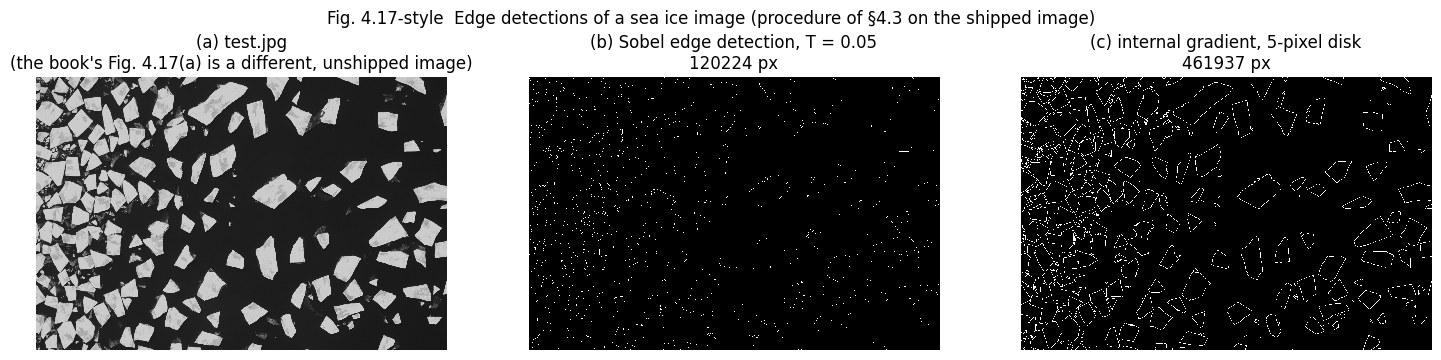

In [16]:
from seaice.ch04_ice_edge_detection import experiment_sobel_thresholds, experiment_internal_gradient
from seaice.core.connectivity import count_components

T0, T1 = BOOK_PARAMS["sobel_T"], BOOK_PARAMS["sobel_T_low"]      # 0.05, 0.03
R0, R1 = BOOK_PARAMS["disk_r_thin"], BOOK_PARAMS["disk_r_thick"]  # 5, 16
IMG_LABEL = "test.jpg" if FROM_BOOK else "substitute image"

# --- Fig. 4.17-style: full frame, Sobel T = 0.05 and internal gradient r = 5 (derivative.m on the whole image) -----
t0 = time.perf_counter()
sob_full = experiment_sobel_thresholds(G, (T0,))
grad_full = experiment_internal_gradient(G, (R0,))
print(f"full frame {G.shape[0]}x{G.shape[1]}: {time.perf_counter() - t0:.1f} s")
print(f"Sobel T = {T0}: {sob_full[T0]['n_edge']} edge px ({100 * sob_full[T0]['n_edge'] / G.size:.3f} %){matlab_ref('120 224 px, 0 differ = derivative.m output')}; "
      f"internal gradient r = {R0}: {grad_full[R0]['n_edge']} px, Otsu t* = {255 * grad_full[R0]['level']:g}")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
imshow_matlab(axes[0], G, title=f"(a) {IMG_LABEL}\n(the book's Fig. 4.17(a) is a different, unshipped image)")
imshow_matlab(axes[1], sob_full[T0]["bw"], title=f"(b) Sobel edge detection, T = {T0}\n{sob_full[T0]['n_edge']} px")
imshow_matlab(axes[2], grad_full[R0]["BW1"], title=f"(c) internal gradient, {R0}-pixel disk\n{grad_full[R0]['n_edge']} px")
fig.suptitle("Fig. 4.17-style  Edge detections of a sea ice image (procedure of §4.3 on the shipped image)")
plt.show()

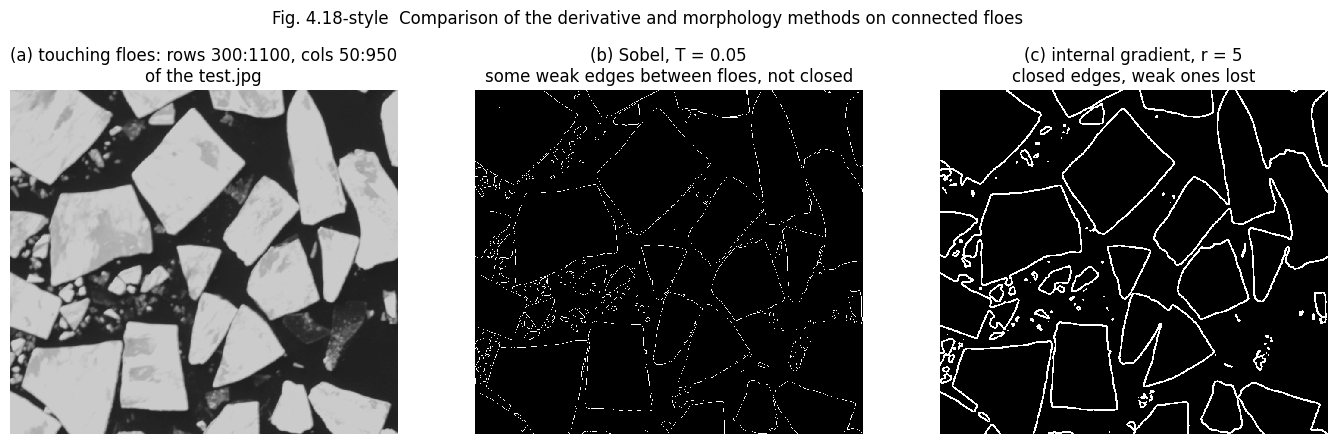

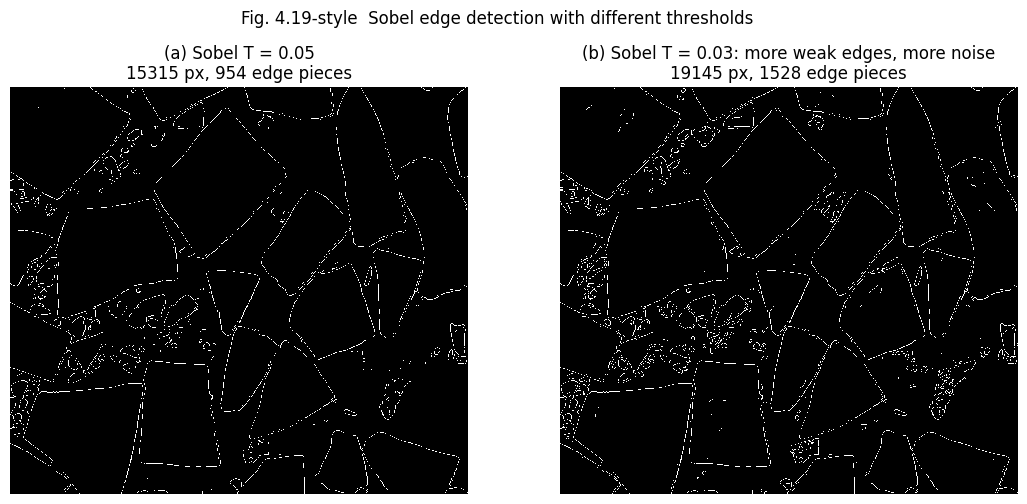

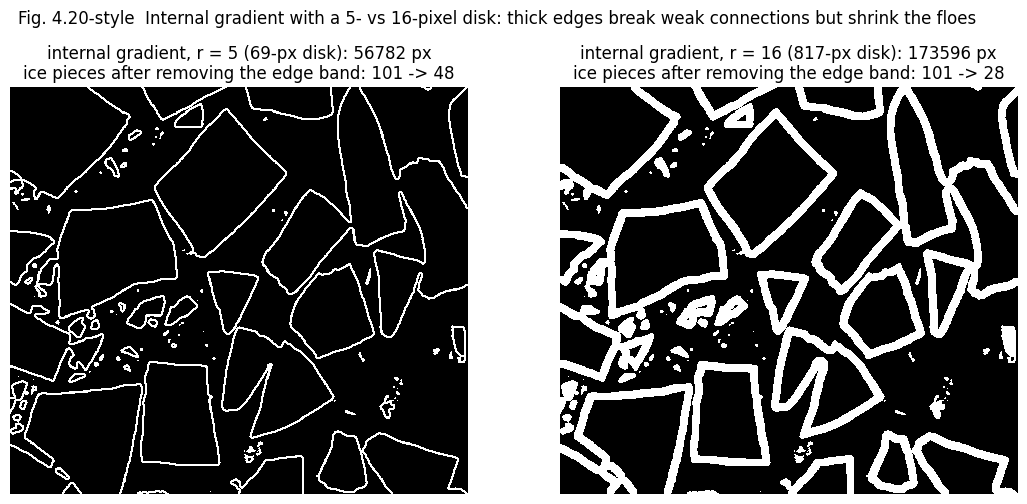

Conclusion of §4.3: neither method separates tightly connected floes -> watershed segmentation (Chapter 5) and the GVF snake (Chapter 6).


In [17]:
crop2 = G[300:1100, 50:950]                           # a region of touching floes (stands in for the unshipped Fig. 4.18(a))
sobc = experiment_sobel_thresholds(crop2, (T0, T1))   # Fig. 4.19: T = 0.05 vs 0.03
gradc = experiment_internal_gradient(crop2, (R0, R1)) # Fig. 4.20: r = 5 vs 16
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
imshow_matlab(axes[0], crop2, title=f"(a) touching floes: rows 300:1100, cols 50:950\nof the {IMG_LABEL}")
imshow_matlab(axes[1], sobc[T0]["bw"], title=f"(b) Sobel, T = {T0}\nsome weak edges between floes, not closed")
imshow_matlab(axes[2], gradc[R0]["BW1"], title=f"(c) internal gradient, r = {R0}\nclosed edges, weak ones lost")
fig.suptitle("Fig. 4.18-style  Comparison of the derivative and morphology methods on connected floes")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
imshow_matlab(axes[0], sobc[T0]["bw"], title=f"(a) Sobel T = {T0}\n{sobc[T0]['n_edge']} px, {count_components(sobc[T0]['bw'], 8)} edge pieces")
imshow_matlab(axes[1], sobc[T1]["bw"], title=f"(b) Sobel T = {T1}: more weak edges, more noise\n{sobc[T1]['n_edge']} px, {count_components(sobc[T1]['bw'], 8)} edge pieces")
fig.suptitle("Fig. 4.19-style  Sobel edge detection with different thresholds")
plt.show()
n_mask = count_components(gradc[R0]["I"], 8)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
for ax, r in zip(axes, (R0, R1)):
    interior = gradc[r]["I"] & (gradc[r]["BW1"] == 0)              # 1-line glue: floes left after removing the edge band
    imshow_matlab(ax, gradc[r]["BW1"], title=f"internal gradient, r = {r} ({int(gradc[r]['SE'].sum())}-px disk): {gradc[r]['n_edge']} px\n"
                                            f"ice pieces after removing the edge band: {n_mask} -> {count_components(interior, 8)}")
fig.suptitle("Fig. 4.20-style  Internal gradient with a 5- vs 16-pixel disk: thick edges break weak connections but shrink the floes")
plt.show()
print("Conclusion of §4.3: neither method separates tightly connected floes -> watershed segmentation (Chapter 5) and the GVF snake (Chapter 6).")

Lowering the Sobel threshold roughly doubles the number of edge fragments — the extra weak edges arrive together
with noise — while a bigger disk turns the internal gradient into a wide band that splits weakly joined floes but
removes a 16-pixel rim from every one of them. Both behaviours are the ones the book describes; the numbers are for
the image loaded here, not for the book's.

## Parameter play (optional)

The two knobs of this chapter on the Fig. 4.3(a) crop: the Sobel threshold $T$ of `edge` and the disk radius $r$ of
the binary internal gradient (Eq. 4.40 of the Otsu mask). Requires `ipywidgets`; the cell prints a message and
falls back to the static preview if it is not installed.

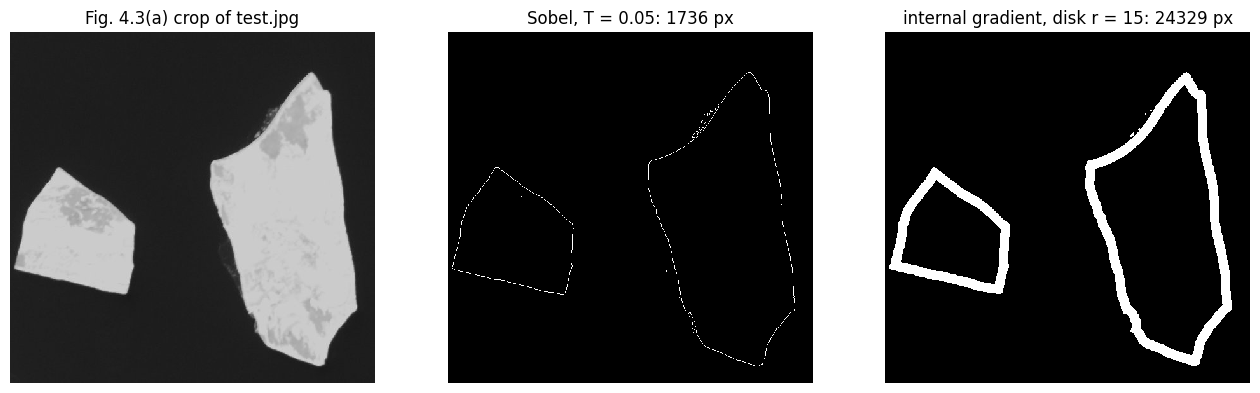

interactive(children=(FloatSlider(value=0.05, description='T', max=0.15, min=0.01, step=0.005), IntSlider(valu…

In [18]:
from seaice.core.morphology import morphological_gradient

I_crop = mo15["I"]                                    # the Otsu mask of the crop (Fig. 4.9(a))

def play(T=0.05, r=15):
    e = sobel_edges_script(crop, T, "sobel")
    g = morphological_gradient(I_crop, strel("disk", r), "internal")
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    imshow_matlab(axes[0], crop, title=CROP_LABEL)
    imshow_matlab(axes[1], e["bw"], title=f"Sobel, T = {T:g}: {e['n_edge']} px")
    imshow_matlab(axes[2], g, title=f"internal gradient, disk r = {r}: {int(g.sum())} px")
    plt.show()

play()                                                # static preview (book values) — visible without widgets
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(play, T=FloatSlider(0.05, min=0.01, max=0.15, step=0.005), r=IntSlider(15, 1, 25, 1))
except ImportError:
    print("ipywidgets not installed - only the static preview above is shown")

## MATLAB ↔ Python mapping used in this chapter

| MATLAB | Python (`seaice`) | Parity | Note |
|---|---|---|---|
| `double(im)/256` | `sobel_edges_script` (literal `/256`) | exact | not `im2double` (/255): the book's $T = 0.05$ refers to the /256 scaling |
| `edge(I, 'sobel'\|'prewitt'\|'roberts', T, dir, 'thinning')` | `core.edges.edge(a, method, thresh, direction, thinning)` → `EdgeResult(bw, thresh, gv, gh)` | exact (196 + 11 maps, 0 px) | `fspecial/8` kernels, replicate padding, `b > T²`, automatic `sqrt(4·mean(b))`, reverse-engineered thinning (`thin_gradient`) |
| `edge(I, 'log', T, sigma)`, `'zerocross'` | `core.edges.edge(..., 'log', sigma=)` / `log_zero_crossings` | exact on images; near on flat synthetic patches | $T$ thresholds the jump across the crossing |
| `edge(I, 'canny')` | not ported (raises) | — | not in the book; `skimage.feature.canny` would be *approx* |
| `fspecial('sobel'\|'prewitt'\|'laplacian'\|'gaussian'\|'log'\|'average'\|'disk')` | `core.filters.fspecial` | exact (≤ 7e-18) | Fig. 4.5 = `fspecial('gaussian', 5, 1)`, `fspecial('log', 5, 1)` |
| `strel('disk', r [, n])`, `'dis'` prefix, `diamond`, `square`, `rectangle`, `line`, `octagon`, … | `core.morphology.strel`, `disk_decomposition` | exact (116 nhoods) | default disk is the n = 4 octagon, not Euclidean; `'di'` is ambiguous in both |
| `imerode`, `imdilate` (logical / uint8 / double) | `core.morphology.imerode`, `imdilate` | exact (108 arrays) | border = 1 / +Inf for erosion, 0 / −Inf for dilation; dilation reflects the SE (Eq. 4.18) |
| `imopen`, `imclose` | `core.morphology.imopen`, `imclose` | exact (54 + 72 cases) | `imclose` pre-pads by `ceil(size/2)` (zero or class-minimum, per MATLAB's routing) |
| `imreconstruct(marker, mask, conn)` | `core.morphology.imreconstruct`; duals `reconstruct_by_erosion`, `geodesic_dilation/erosion`, `reconstruct_iterative` | exact / reimplemented | `marker <= mask` required, as in MATLAB |
| `I − J` (logical), `im − X` (uint8) | `core.morphology.morphological_gradient(I, se, kind)` | exact | logical − logical → double; uint8 saturates |
| `graythresh`, `im2bw`, `rgb2gray` | `core.threshold.graythresh / im2bw`, `matlab_compat.rgb2gray_matlab` | exact (Chapters 2–3) | |
| `medfilt2`, `bwareaopen`, `conv2` (commented lines of `derivative.m`) | `sobel_edges_script(median=, min_area=, smooth=)`, `ch04.bwareaopen`, `core.filters.conv2` | exact | `conv2` default `'full'` grows the map to (r+4)×(c+4) |

## Summary — and what the next chapters need from this one

**What chapter 4 established.** Floe boundaries can be found from the first derivative (Sobel / Prewitt magnitude
thresholded at $T$, Eqs. 4.2–4.8; thinned to one-pixel ridges by MATLAB's `edge`), from zero-crossings of the
Laplacian of Gaussian (Eqs. 4.9–4.15; noisier), or from the morphological gradients of the Otsu ice mask
(Eqs. 4.39–4.42; closed edges whose width is the SE radius). Behind the latter sit the morphological primitives —
structuring elements, erosion / dilation (Eqs. 4.16–4.21), opening / closing (4.22–4.23) and reconstruction
(4.24–4.38) — which the rest of the book uses far more than the edge maps themselves. None of the edge detectors
separates touching floes: Sobel leaves weak edges open, the internal gradient loses them or, with a big disk, shrinks
the floes.

**Parity (from `reports/ch04_verification.md`, MATLAB R2025a as reference).** Both `.m` files are `exact`:
`derivative.m`'s edge map and 11 `edge` variants are 0 px from MATLAB on the 12.25-Mpx image, all 12 arrays of
`morphology.m` are 0 px / 0 levels, and the crop + r = 15 configuration of Figs. 4.3 / 4.6 / 4.9 / 4.10 / 4.15 / 4.16
is 0 px as well (27 figure images identical). `exact` also: `fspecial` (26 kernels), `strel` (116 neighbourhoods),
`imerode` / `imdilate` (108), `imopen` (54), `imclose` (72), `imreconstruct` (7), `bwareaopen`, `medfilt2`, `conv2`.
`near`: `edge('log')` on piecewise-constant synthetic images (rounding-noise signs). `reimplemented`: the
book-equation forms (`gradient_operator`, `laplacian`, `laplacian_zero_crossings`, analytic `log_kernel`, geodesic
iteration). `unverified`: Figs. 4.17–4.20 (source image not shipped). 485 tests pass.

**Feeds forward (`seaice/core/` primitives the later chapters import):**

| Needed by | Primitive |
|---|---|
| Ch5 (watershed floe segmentation) | `morphology.strel('disk', r)`, `imerode` / `imdilate`, `imreconstruct` (basis of `imimposemin`, `imregionalmin`, `imfill`), `morphological_gradient` (gradient surface for the watershed), `filters.fspecial('gaussian')` smoothing before the distance-transform markers; all bit-exact, so marker images can be compared with 0-px tolerance |
| Ch6 (GVF snake) | `core.edges.edge` and `fspecial('gaussian')` for the edge map that drives the GVF field; `imdilate` of contour masks |
| Ch7 (ice types, shape enhancement) | `imopen` / `imclose` with disks (the `imclose` border rule matters there), reconstruction, `bwareaopen` |
| Ch8–Ch9 (applications, model ice) | `strel` + gradients for floe-boundary statistics; `edge` for the tank-image floe outlines |

**Pitfalls to carry forward.** `edge` takes a float image and `derivative.m` scales with `/256`, not `im2double`;
MATLAB's `edge` thins and uses `/8` kernels, so Eq. (4.2) alone does not reproduce Fig. 4.3; the LoG threshold is on
the jump across the zero crossing; `strel('disk', r)` is an octagon (never use `skimage.morphology.disk` for
parity) and `'dis'` is a prefix match; erosion pads with 1 / +Inf, dilation with 0 / −Inf and reflects the SE;
`imclose` is not the bare `imerode(imdilate(A))` at the border; logical − logical is `double` and uint8 − uint8
saturates in MATLAB; Fig. 4.15's "157-pixel radius" is a typo for 15 (157 is the pixel count of `strel('dis', 7)`).

*Optional: to regenerate the MATLAB references yourself, run `reference/ch04/make_refs.py` (uses
`tools/run_matlab_ref.py`, MATLAB `-batch`); the notebook does not need MATLAB or Octave.*